## Visualizacion de DEMO_H

In [509]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_demo = pd.read_csv("../data/demo.csv")
df_dpq = pd.read_csv('../data/processed/dpq_limpio.csv')


In [510]:
df_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6106 entries, 0 to 6105
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SEQN                    6106 non-null   float64
 1   Genero                  6106 non-null   float64
 2   Edad                    6106 non-null   float64
 3   Etnia                   6106 non-null   float64
 4   Nivel_Educativo         6106 non-null   float64
 5   Estado_Civil            6106 non-null   float64
 6   Ratio_Pobreza           6106 non-null   float64
 7   Servicio_Militar        6106 non-null   float64
 8   Ratio_Pobreza_Faltante  6106 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 429.5 KB


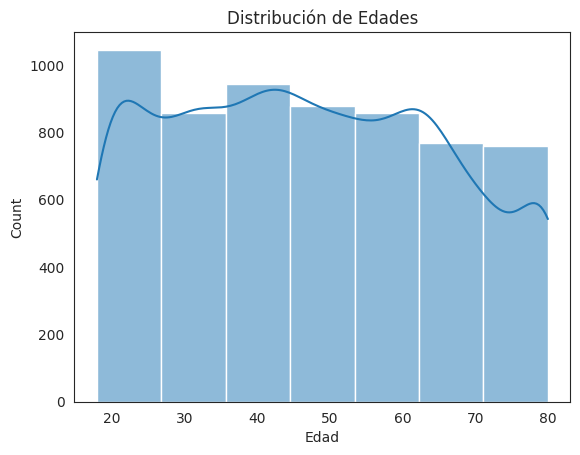

In [511]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df_demo, x="Edad", bins=7, kde=True)
plt.title("Distribución de Edades")
plt.show()

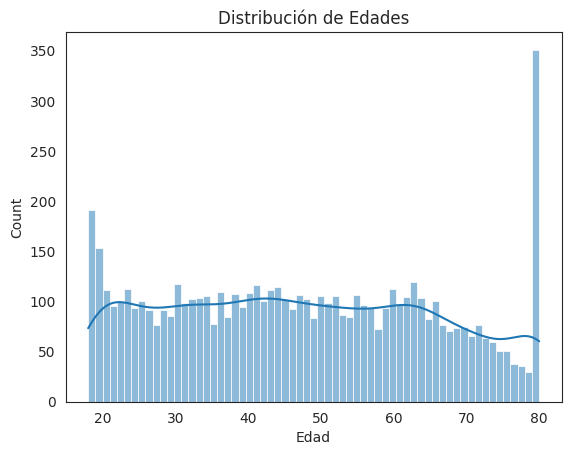

In [512]:
sns.histplot(data=df_demo, x="Edad", bins=63, kde=True)
plt.title("Distribución de Edades")
plt.show()

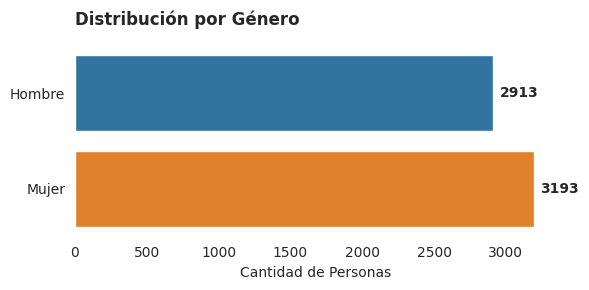

In [513]:
plt.figure(figsize=(6, 3))
ax = sns.countplot(
    data=df_demo, 
    y="Genero", 
    hue="Genero", # Mejora la consistencia visual
    legend=False,
    palette='tab10'
)
plt.yticks(ticks=[0, 1], labels=["Hombre", "Mujer"])
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, fontweight='bold')

plt.title("Distribución por Género", fontsize=12, pad=15, loc='left', fontweight='bold')
plt.xlabel("Cantidad de Personas")
plt.ylabel("") # Quitamos "Genero" porque ya se entiende por las etiquetas
sns.despine(left=True, bottom=True) # Quitamos los bordes innecesarios

plt.tight_layout()
plt.show()

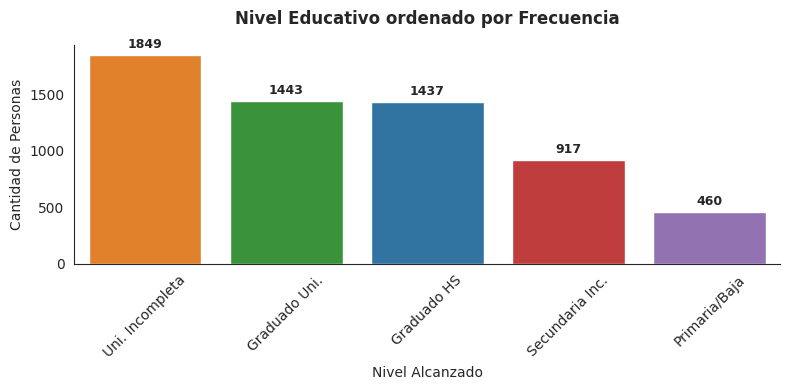

In [514]:
nombres_educacion = {
    1: "Primaria/Baja",
    2: "Secundaria Inc.",
    3: "Graduado HS",
    4: "Uni. Incompleta",
    5: "Graduado Uni."
}

df_demo['Educacion_Label'] = df_demo['Nivel_Educativo'].map(nombres_educacion)

orden_frecuencia = df_demo['Educacion_Label'].value_counts().index

plt.figure(figsize=(8, 4))
ax = sns.countplot(
    x='Educacion_Label', 
    data=df_demo, 
    order=orden_frecuencia, 
    palette='tab10', 
    hue='Educacion_Label',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9, fontweight='bold')

plt.title('Nivel Educativo ordenado por Frecuencia', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nivel Alcanzado')
plt.ylabel('Cantidad de Personas')
plt.xticks(rotation=45)

# Eliminamos bordes para máxima limpieza
sns.despine()

plt.tight_layout()
plt.show()

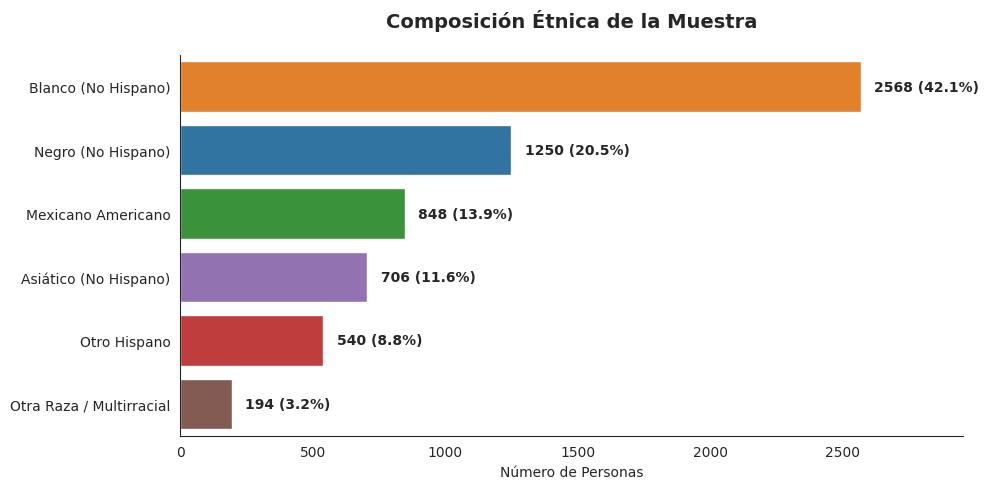

In [515]:
dict_etnia = {
    1: "Mexicano Americano",
    2: "Otro Hispano",
    3: "Blanco (No Hispano)",
    4: "Negro (No Hispano)",
    6: "Asiático (No Hispano)",
    7: "Otra Raza / Multirracial"
}
df_demo['Etnia_Label'] = df_demo['Etnia'].map(dict_etnia)

orden_frecuencia = df_demo['Etnia_Label'].value_counts().index

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df_demo, 
    y='Etnia_Label', 
    order=orden_frecuencia, 
    palette='tab10',
    hue='Etnia_Label',
    legend=False
)

total = len(df_demo)
for p in ax.patches:
    percentage = f'{100 * p.get_width() / total:.1f}%'
    x = p.get_width() + 50 # Un pequeño offset
    y = p.get_y() + p.get_height() / 2
    ax.annotate(f'{int(p.get_width())} ({percentage})', (x, y), va='center', fontweight='bold')

plt.title('Composición Étnica de la Muestra', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Número de Personas')
plt.ylabel('')
plt.xlim(0, df_demo['Etnia_Label'].value_counts().max() * 1.15) # Espacio para que quepan las etiquetas
sns.despine()

plt.tight_layout()
plt.show()

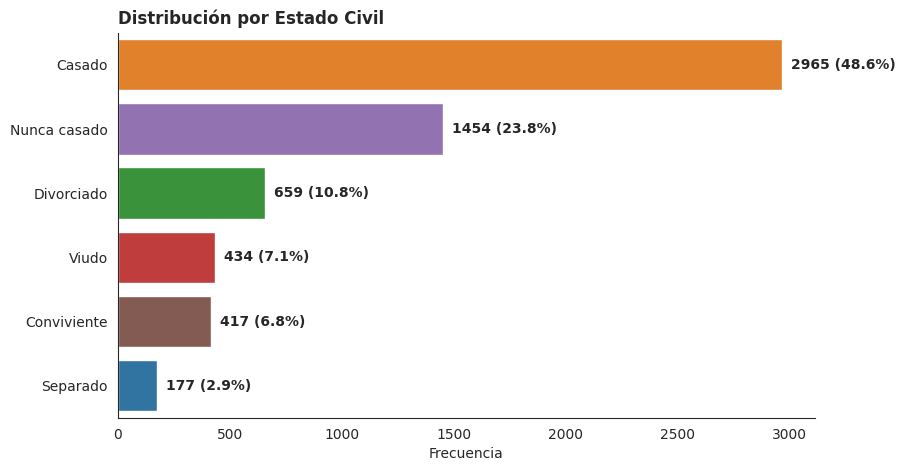

In [516]:
# 1. Diccionario de traducción
dict_civil = {
    1: "Casado",
    2: "Viudo",
    3: "Divorciado",
    4: "Separado",
    5: "Nunca casado",
    6: "Conviviente"
}

# 2. Creamos la columna y filtramos los valores no informativos (77, 99 y NaNs)
df_demo['Estado_Civil_Label'] = df_demo['Estado_Civil'].map(dict_civil)
df_civil_clean = df_demo.dropna(subset=['Estado_Civil_Label'])
plt.figure(figsize=(9, 5))
orden_civil = df_civil_clean['Estado_Civil_Label'].value_counts().index

ax = sns.countplot(
    data=df_civil_clean, 
    y='Estado_Civil_Label', 
    order=orden_civil, 
    palette='tab10',
    hue='Estado_Civil_Label',
    legend=False
)

# Añadimos porcentajes
total_valido = len(df_civil_clean)
for p in ax.patches:
    pct = f'{100 * p.get_width() / total_valido:.1f}%' # pyright: ignore[reportAttributeAccessIssue]
    ax.annotate(f'{int(p.get_width())} ({pct})', 
                (p.get_width() + 40, p.get_y() + p.get_height()/2), 
                va='center', fontweight='bold')

plt.title('Distribución por Estado Civil', loc='left', fontweight='bold')
plt.xlabel('Frecuencia')
plt.ylabel('')
sns.despine()
plt.show()

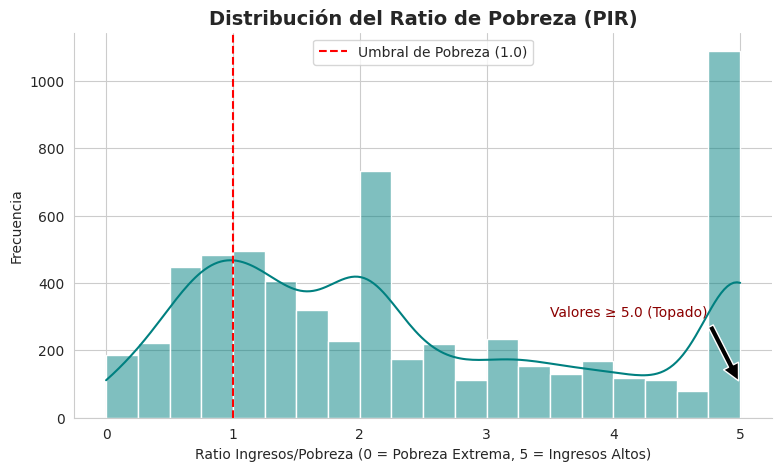

In [517]:
plt.figure(figsize=(9, 5))
sns.set_style("whitegrid")

# Crear el histograma
ax = sns.histplot(data=df_demo, x="Ratio_Pobreza", kde=True, color="teal", bins=20)

# EL TOQUE DE EXPERTO: Añadir la línea del umbral de pobreza
plt.axvline(x=1.0, color='red', linestyle='--', label='Umbral de Pobreza (1.0)')

# Anotación para explicar el "pico" en 5.0
plt.annotate('Valores ≥ 5.0 (Topado)', xy=(5, 100), xytext=(3.5, 300),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, color='darkred')

plt.title('Distribución del Ratio de Pobreza (PIR)', fontsize=14, fontweight='bold')
plt.xlabel('Ratio Ingresos/Pobreza (0 = Pobreza Extrema, 5 = Ingresos Altos)')
plt.ylabel('Frecuencia')
plt.legend()
sns.despine()

plt.show()

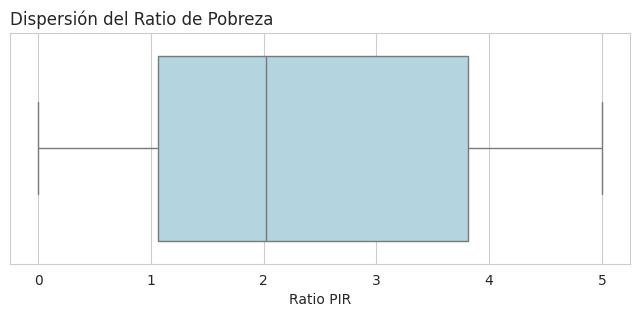

In [518]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df_demo, x="Ratio_Pobreza", color="lightblue", fliersize=3)

plt.title('Dispersión del Ratio de Pobreza', loc='left')
plt.xlabel('Ratio PIR')
plt.show()

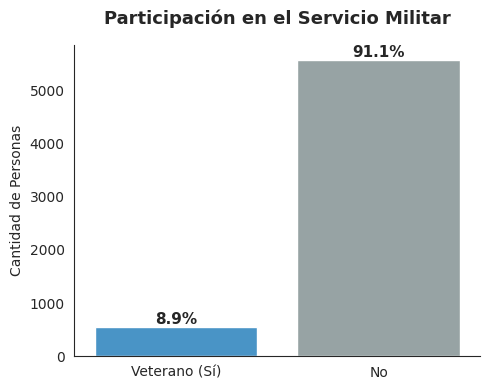

In [519]:
# 1. Mapeo de valores
dict_militar = {1: "Veterano (Sí)", 2: "No"}
df_demo['Servicio_Militar_Label'] = df_demo['Servicio_Militar'].map(dict_militar)

# 2. Configuración estética
plt.figure(figsize=(5, 4))
sns.set_style("white")

# 3. Gráfico de barras
# Usamos una paleta de dos colores contrastantes (Gris para 'No', Azul para 'Veterano')
colores = ["#95a5a6", "#3498db"] # Gris y Azul

ax = sns.countplot(
    data=df_demo.dropna(subset=['Servicio_Militar_Label']), 
    x='Servicio_Militar_Label', 
    palette=colores[::-1], # Invertimos para que Veterano sea azul si es el primero
    hue='Servicio_Militar_Label',
    legend=False
)

# 4. Añadir porcentajes sobre las barras
total = len(df_demo.dropna(subset=['Servicio_Militar_Label']))
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 5), 
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# 5. Limpieza final
plt.title('Participación en el Servicio Militar', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('')
plt.ylabel('Cantidad de Personas')
sns.despine()

plt.tight_layout()
plt.show()

### Analisis multivariable

In [520]:
df_final = pd.merge(df_demo, df_dpq, on='SEQN', how='inner')

In [521]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5371 entries, 0 to 5370
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SEQN                    5371 non-null   float64
 1   Genero                  5371 non-null   float64
 2   Edad                    5371 non-null   float64
 3   Etnia                   5371 non-null   float64
 4   Nivel_Educativo         5371 non-null   float64
 5   Estado_Civil            5371 non-null   float64
 6   Ratio_Pobreza           5371 non-null   float64
 7   Servicio_Militar        5371 non-null   float64
 8   Ratio_Pobreza_Faltante  5371 non-null   int64  
 9   Educacion_Label         5371 non-null   object 
 10  Etnia_Label             5371 non-null   object 
 11  Estado_Civil_Label      5371 non-null   object 
 12  Servicio_Militar_Label  5371 non-null   object 
 13  score_depresion         5371 non-null   float64
dtypes: float64(9), int64(1), object(4)
memor

<Figure size 1200x600 with 0 Axes>

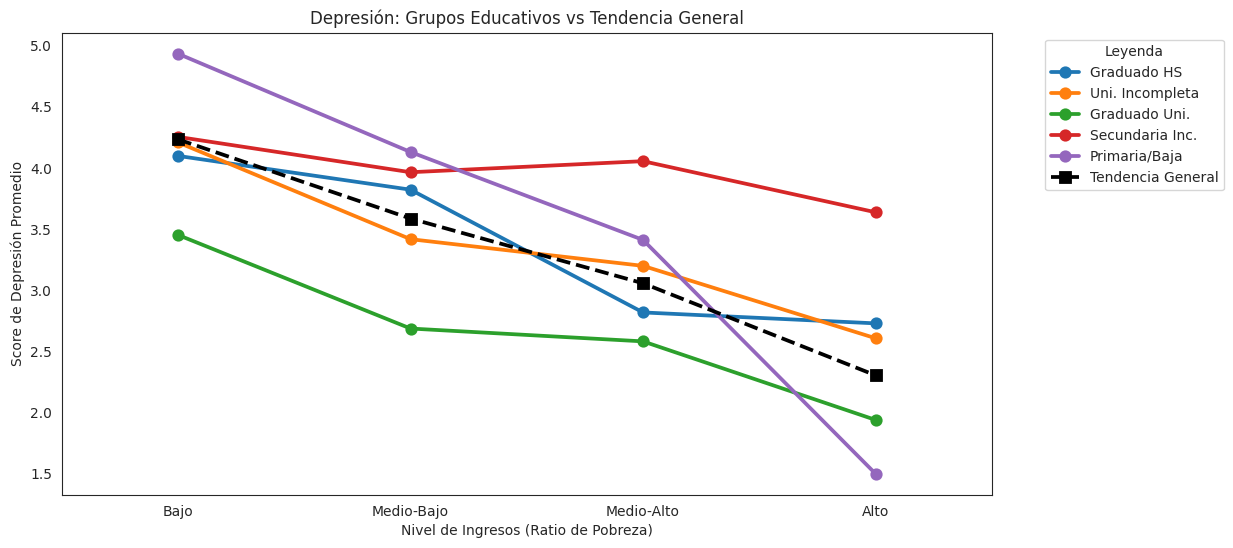

In [522]:
plt.figure(figsize=(12, 6))
# Dividimos la pobreza en cuartiles para que sea más legible
df_final["pobreza_grupo"] = pd.qcut(
    df_final["Ratio_Pobreza"], 4, labels=["Bajo", "Medio-Bajo", "Medio-Alto", "Alto"]
)

plt.figure(figsize=(12, 6))

# 1. El gráfico por grupos (Educación)
sns.pointplot(data=df_final, x='pobreza_grupo', y='score_depresion', 
              hue='Educacion_Label', palette='tab10', errorbar=None)

# 2. El gráfico de tendencia general (sin 'hue')
sns.pointplot(data=df_final, x='pobreza_grupo', y='score_depresion', 
              color='black', markers='s', linestyles='--', label='Tendencia General', errorbar=None)

plt.title("Depresión: Grupos Educativos vs Tendencia General")
plt.xlabel("Nivel de Ingresos (Ratio de Pobreza)")
plt.ylabel("Score de Depresión Promedio")
plt.legend(title="Leyenda", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

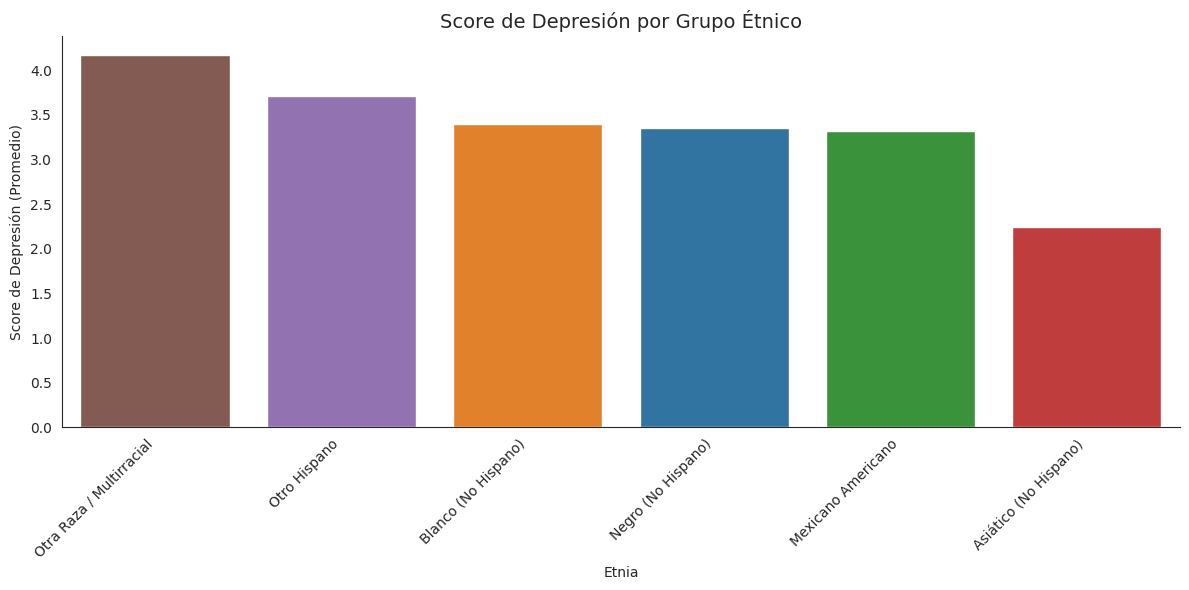

In [523]:
plt.figure(figsize=(12, 6))

# Calculamos el orden para que el gráfico sea más fácil de leer
orden = df_final.groupby('Etnia_Label')['score_depresion'].mean().sort_values(ascending=False).index

# Graficamos solo el promedio por etnia
sns.barplot(
    data=df_final, 
    x='Etnia_Label', 
    y='score_depresion', 
    order=orden,          
    palette='tab10',    
    errorbar=None,
    hue='Etnia_Label',    
    legend=False
)

plt.title("Score de Depresión por Grupo Étnico", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Score de Depresión (Promedio)")
plt.xlabel("Etnia")

sns.despine() # Limpiamos los bordes superior y derecho
plt.tight_layout()
plt.show()

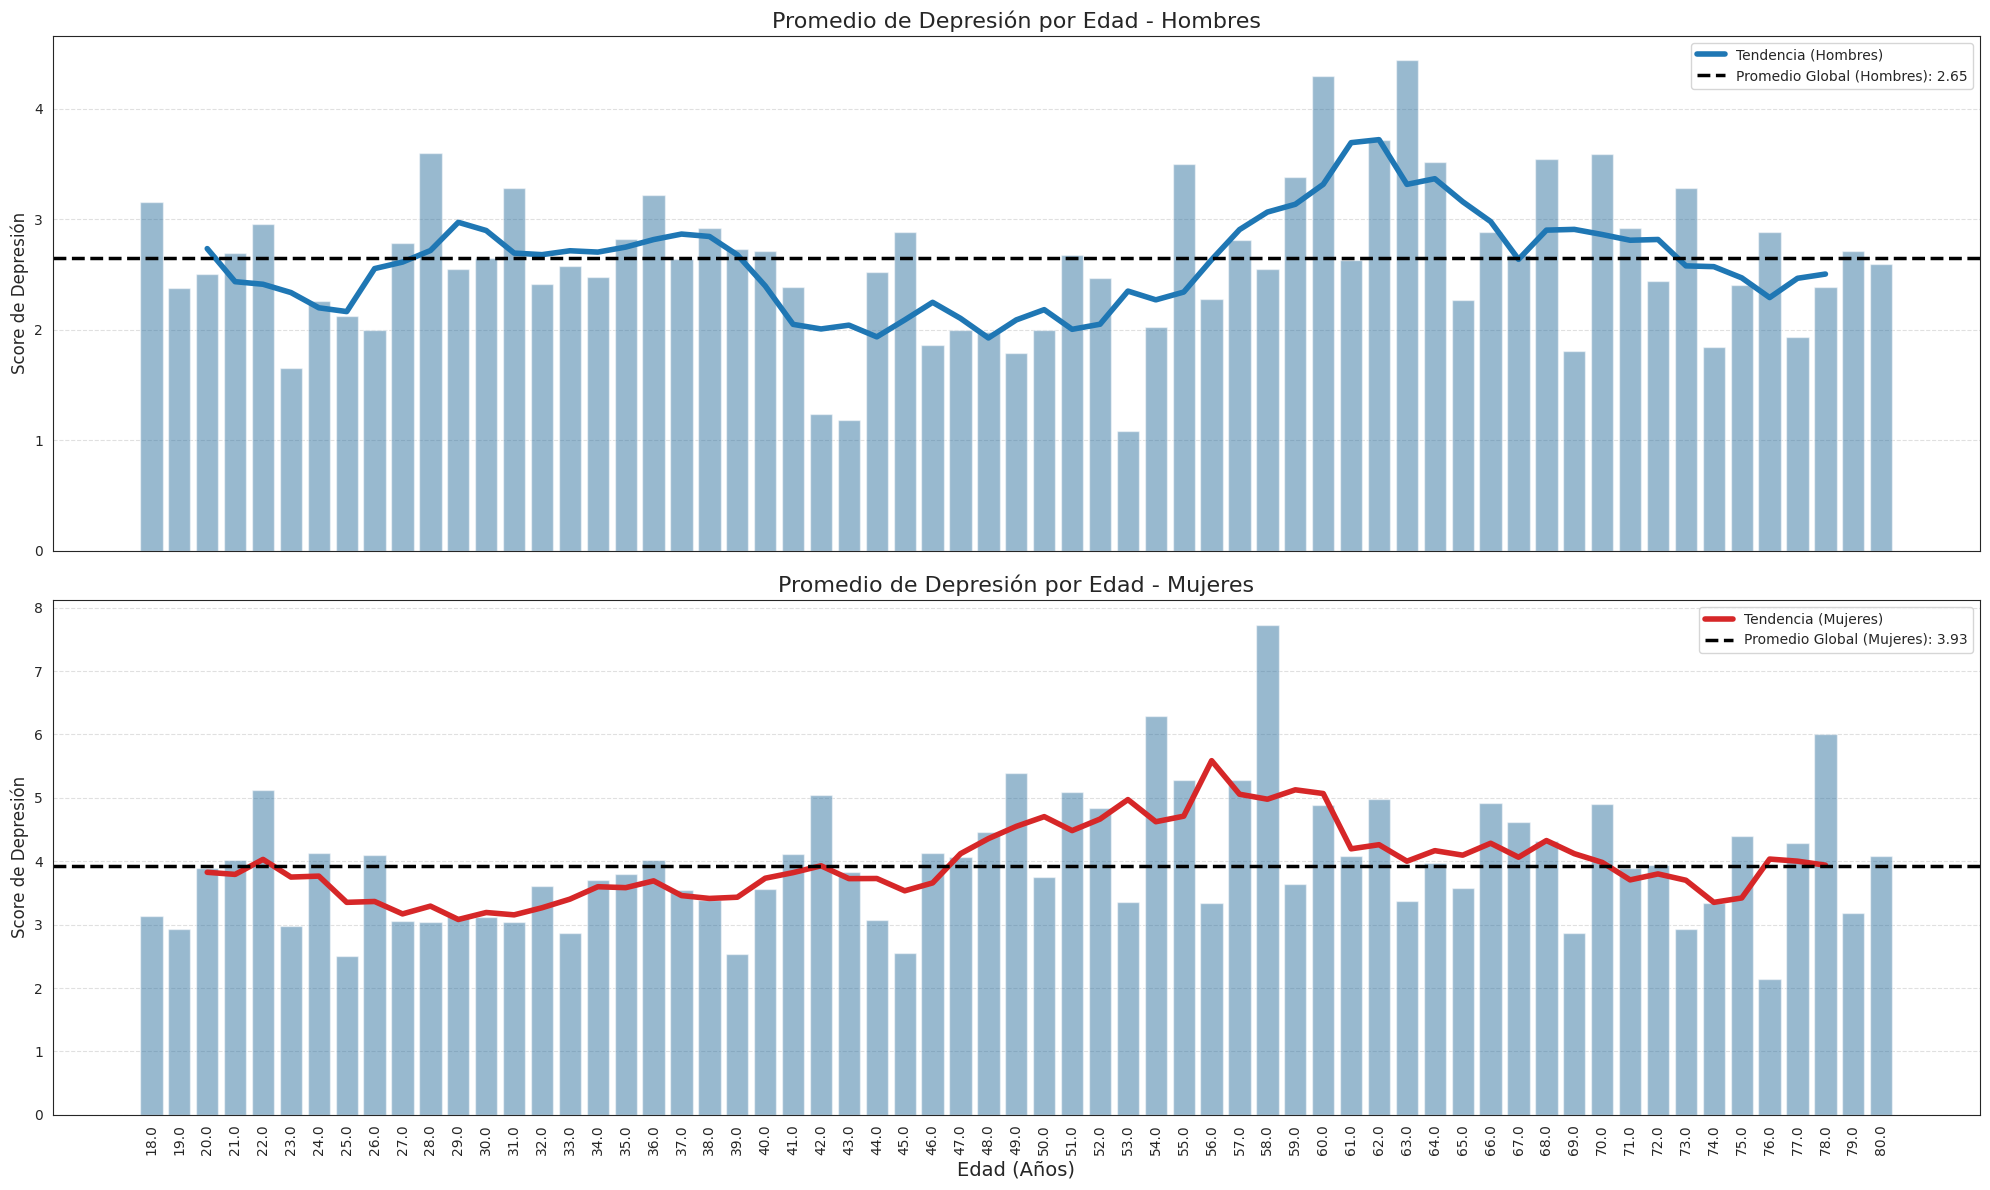

In [524]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos los valores de tu columna 'Genero' para iterar
valores_genero = [1.0, 2.0]
nombres_genero = {1.0: 'Hombres', 2.0: 'Mujeres'}
colores_linea = {1.0: '#1f77b4', 2.0: '#d62728'} # Azul para Hombres, Rojo para Mujeres

# 1. Configurar la figura con 2 filas y 1 columna
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20, 12), sharex=True)

# 2. Iteramos sobre cada género para crear su gráfico
for i, genero in enumerate(valores_genero):
    ax = axes[i] # Seleccionamos el subgráfico actual (arriba o abajo)
    
    # Filtramos los datos solo para el género actual
    df_genero = df_final[df_final['Genero'] == genero]
    
    # Preparamos los datos para la línea suavizada de este género
    df_tendencia = df_genero.groupby('Edad')['score_depresion'].mean().rolling(window=5, center=True).mean().reset_index()
    
    # Dibujamos las barras en el eje específico (ax=ax)
    sns.barplot(
        data=df_genero, 
        x='Edad', 
        y='score_depresion', 
        errorbar=None, 
         
        alpha=0.5,
        ax=ax
    )
    
    # Dibujamos la línea de tendencia en el mismo eje (ax=ax)
    sns.lineplot(
        x=range(len(df_tendencia)), 
        y=df_tendencia['score_depresion'], 
        color=colores_linea[genero], 
        linewidth=4, 
        label=f'Tendencia ({nombres_genero[genero]})',
        ax=ax
    )
    
    # --- NUEVA SECCIÓN: LÍNEA DE PROMEDIO GENERAL ---
    # Calculamos el promedio de TODOS los registros para este género
    promedio_general = df_genero['score_depresion'].mean()
    
    # Dibujamos la línea horizontal (axhline)
    ax.axhline(
        y=promedio_general, 
        color='black',      # Color negro para que resalte
        linestyle='--',     # Línea punteada
        linewidth=2.5, 
        label=f'Promedio Global ({nombres_genero[genero]}): {promedio_general:.2f}'
    )
    # ------------------------------------------------
    
    # Ajustes estéticos de cada subgráfico
    ax.set_title(f'Promedio de Depresión por Edad - {nombres_genero[genero]}', fontsize=16)
    ax.set_ylabel('Score de Depresión', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    # La leyenda ahora incluirá también el promedio general automáticamente
    ax.legend(loc='upper right')
    
    # Rotar las etiquetas de edad para que se lean bien
    ax.tick_params(axis='x', rotation=90)

# Etiqueta general para el eje X en la parte inferior
plt.xlabel('Edad (Años)', fontsize=14)

# Ajustar el espaciado para que no se superpongan los títulos
plt.tight_layout()
plt.show()

/tmp/ipykernel_338207/2243287366.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


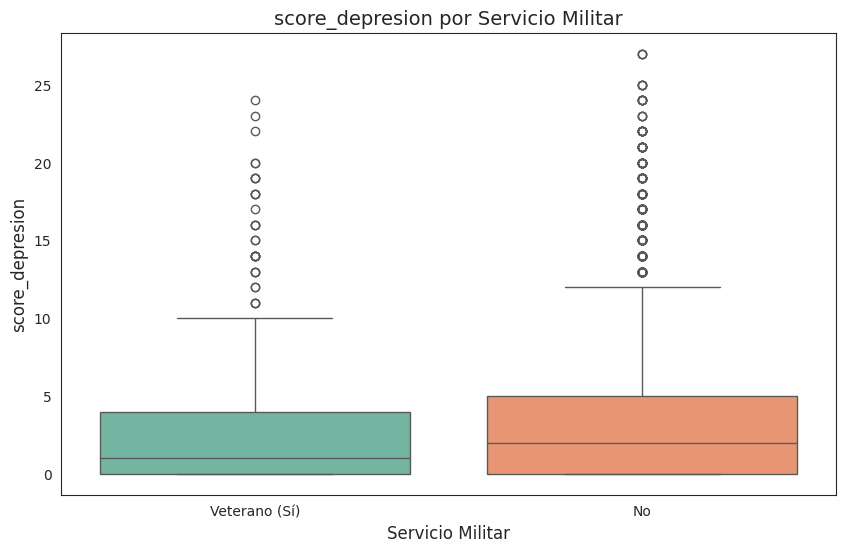

In [525]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_final, 
    x='Servicio_Militar_Label', 
    y='score_depresion', 
    palette='Set2'
)

plt.title('score_depresion por Servicio Militar', fontsize=14)
plt.xlabel('Servicio Militar', fontsize=12)
plt.ylabel('score_depresion', fontsize=12)
plt.show()

## ALQ_H

In [526]:
df_alq = pd.read_csv('../data/alq.csv')

In [527]:
df_alq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5909 entries, 0 to 5908
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SEQN                          5909 non-null   float64
 1   Promedio_Tragos_Dia           5909 non-null   float64
 2   Dias_Con_+4_5_Tragos_En_2hrs  5909 non-null   float64
 3   Consumio_Alcohol              5909 non-null   bool   
 4   Dias_Consumo_Anual            5909 non-null   float64
 5   Dias_Alto_Consumo_Anual       5909 non-null   float64
dtypes: bool(1), float64(5)
memory usage: 236.7 KB


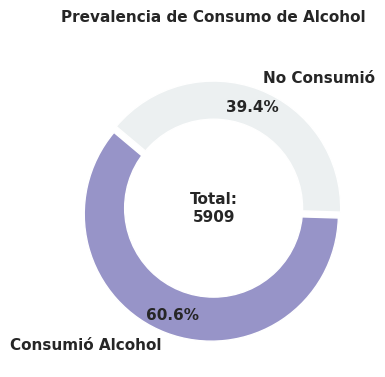

In [528]:
import matplotlib.pyplot as plt

# 1. Preparar los datos
conteo = df_alq['Consumio_Alcohol'].value_counts()
etiquetas = ['Consumió Alcohol', 'No Consumió']
colores = ["#9794c8", '#ecf0f1'] # Gris oscuro (activo) y gris muy claro (neutro)

# 2. Crear el gráfico de dona
plt.figure(figsize=(4, 4))
plt.pie(
    conteo, 
    labels=etiquetas, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colores, 
    pctdistance=0.85, 
    explode=(0.05, 0), # Separa un poco la tajada del "Sí"
    textprops={'fontweight': 'bold', 'fontsize': 11}
)

# 3. Dibujar el círculo blanco central (la dona)
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

# 4. Información central
plt.text(0, 0, f'Total:\n{len(df_alq)}', ha='center', va='center', fontsize=11, fontweight='bold')

plt.title('Prevalencia de Consumo de Alcohol', fontsize=11, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

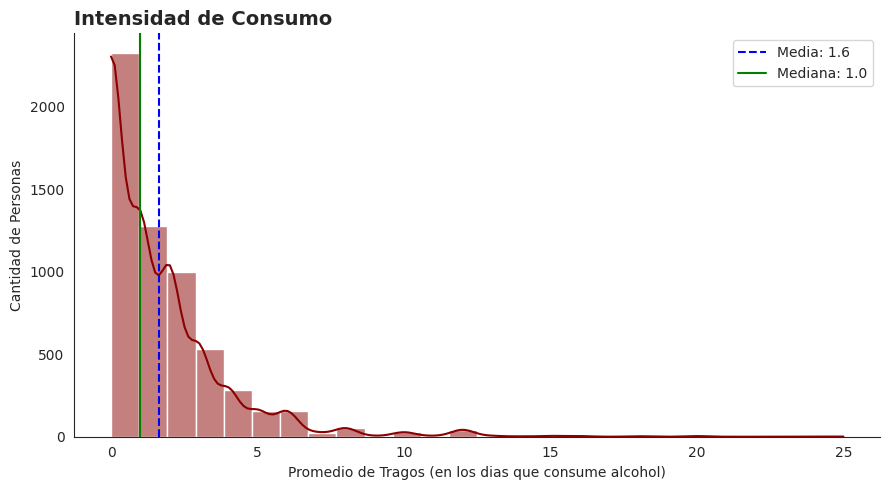

In [529]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo
sns.set_style("white")
plt.figure(figsize=(9, 5))

# 2. Creación del gráfico
# Usamos bins para agrupar los tragos y KDE para ver la forma de la distribución
ax = sns.histplot(data=df_alq, x="Promedio_Tragos_Dia", kde=True, color="darkred", bins=26)

# 3. EL TOQUE DE EXPERTO: Añadir líneas de tendencia central
media = df_alq["Promedio_Tragos_Dia"].mean()
mediana = df_alq["Promedio_Tragos_Dia"].median()

plt.axvline(media, color='blue', linestyle='--', label=f'Media: {media:.1f}')
plt.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.1f}')

# 5. Limpieza y etiquetas
plt.title('Intensidad de Consumo', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('Promedio de Tragos (en los dias que consume alcohol)')
plt.ylabel('Cantidad de Personas')
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

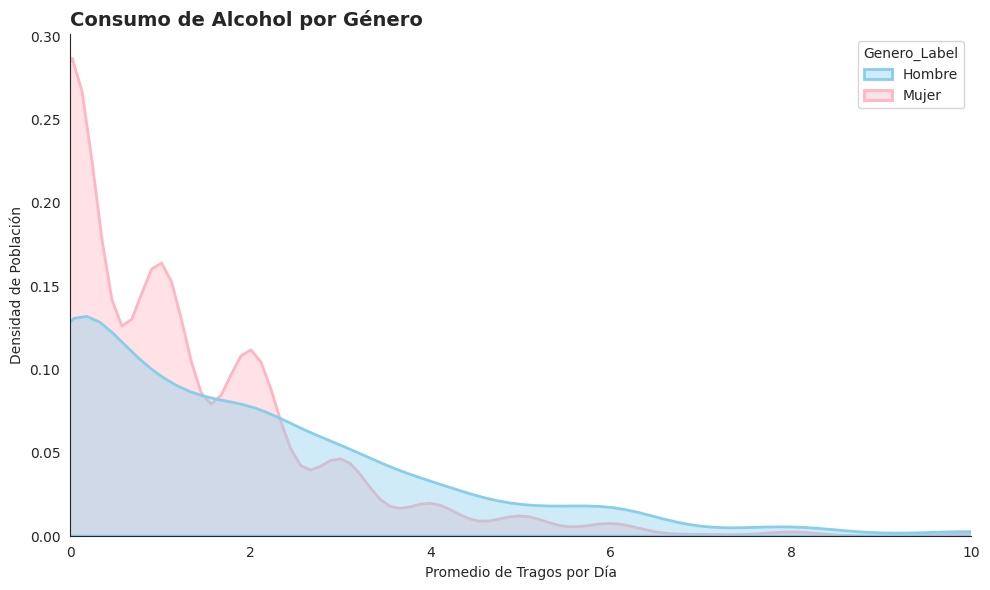

In [530]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Unión y preparación (Igual que el tuyo, gemelo)
df_consolidado = pd.merge(df_demo, df_alq[['SEQN', 'Promedio_Tragos_Dia']], on='SEQN', how='inner')
df_consolidado['Genero_Label'] = df_consolidado['Genero'].map({1: "Hombre", 2: "Mujer"})

# 2. Configuración estética
plt.figure(figsize=(10, 6))
sns.set_style("white")

# 3. Gráfico de Densidad
sns.kdeplot(
    data=df_consolidado, 
    x="Promedio_Tragos_Dia", 
    hue="Genero_Label", 
    fill=True, 
    palette=["skyblue", "lightpink"], 
    alpha=0.4, 
    linewidth=2
)

# 4. Cálculo de estadísticas por grupo
stats = df_consolidado.groupby('Genero_Label')['Promedio_Tragos_Dia'].agg(['mean', 'median'])

# 5. Superposición de Media y Mediana
colores = {"Hombre": "steelblue", "Mujer": "palevioletred"}


# 6. Pulido del gráfico
plt.title('Consumo de Alcohol por Género', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('Promedio de Tragos por Día')
plt.ylabel('Densidad de Población')
plt.xlim(0, 10) # Enfocamos en el grueso de la población
sns.despine()

plt.tight_layout()
plt.show()

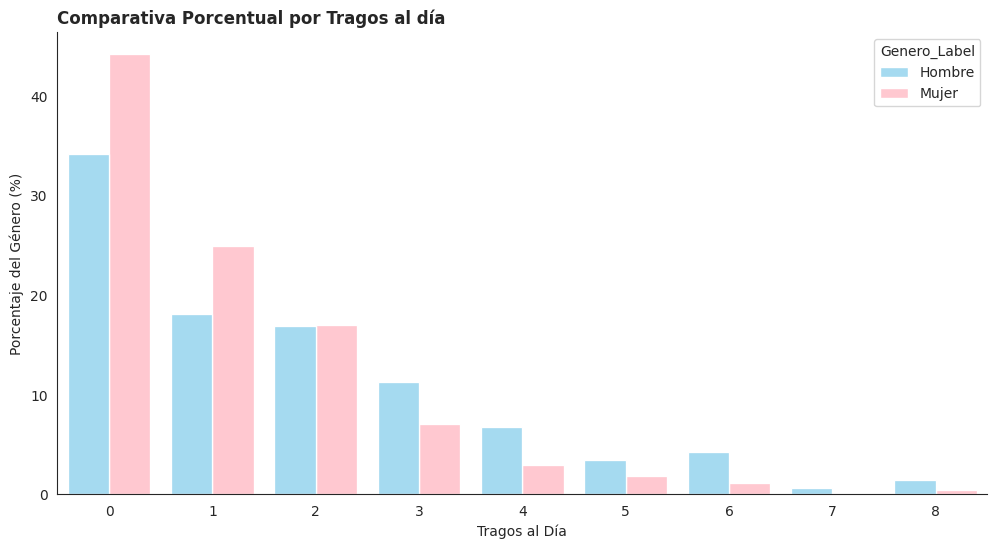

In [531]:
plt.figure(figsize=(12, 6))

# Usamos 'discrete=True' para que las barras caigan exacto en los números
sns.histplot(
    data=df_consolidado,
    x="Promedio_Tragos_Dia",
    hue="Genero_Label",
    multiple="dodge", # Pone las barras una al lado de la otra
    shrink=0.8,       # Les da un poco de aire entre ellas
    palette=["skyblue", "lightpink"],
    discrete=True,
    stat="percent",   # Importante: muestra porcentaje para que sean comparables
    common_norm=False # Calcula el % independiente por cada género
)

plt.title('Comparativa Porcentual por Tragos al día', loc='left', fontweight='bold')
plt.xlabel('Tragos al Día')
plt.ylabel('Porcentaje del Género (%)')
plt.xlim(-0.5, 8.5) # Enfocamos en el grueso de la población
plt.xticks(range(9))
sns.despine()
plt.show()

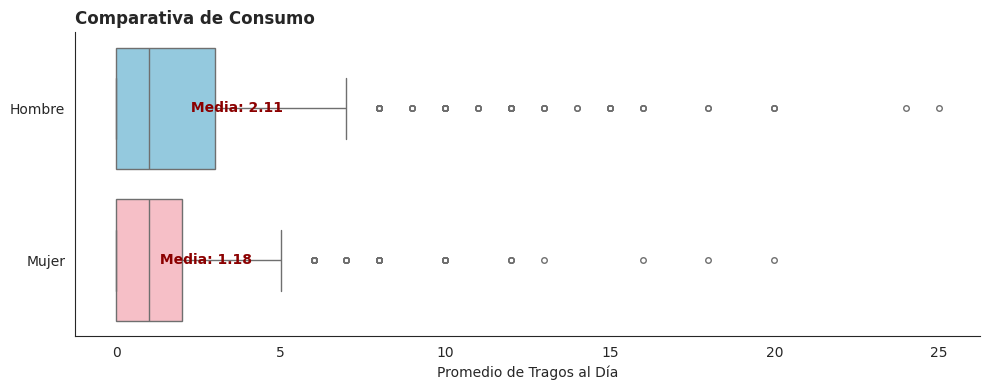

In [532]:
# 1. Calculamos la asimetría por género
skew_h = df_consolidado[df_consolidado['Genero'] == 1]['Promedio_Tragos_Dia'].skew()
skew_m = df_consolidado[df_consolidado['Genero'] == 2]['Promedio_Tragos_Dia'].skew()



# 2. Visualización: Boxplot con estilo impecable
plt.figure(figsize=(10, 4))
sns.set_style("white")

ax = sns.boxplot(
    data=df_consolidado, 
    x="Promedio_Tragos_Dia", 
    y="Genero_Label", 
    palette=["skyblue", "lightpink"],
    hue="Genero_Label",
    legend=False,
    fliersize=4  # Tamaño de los puntos atípicos
)

# 3. Anotamos las Medias para contrastar con las medianas iguales
medias = df_consolidado.groupby('Genero_Label')['Promedio_Tragos_Dia'].mean()

for i, genero in enumerate(['Hombre', 'Mujer']):
    plt.text(medias[genero], i, f' Media: {medias[genero]:.2f}', 
             va='center', fontweight='bold', color='darkred', fontsize=10)

plt.title('Comparativa de Consumo', loc='left', fontweight='bold')
plt.xlabel('Promedio de Tragos al Día')
plt.ylabel('')
sns.despine()

plt.tight_layout()
plt.show()

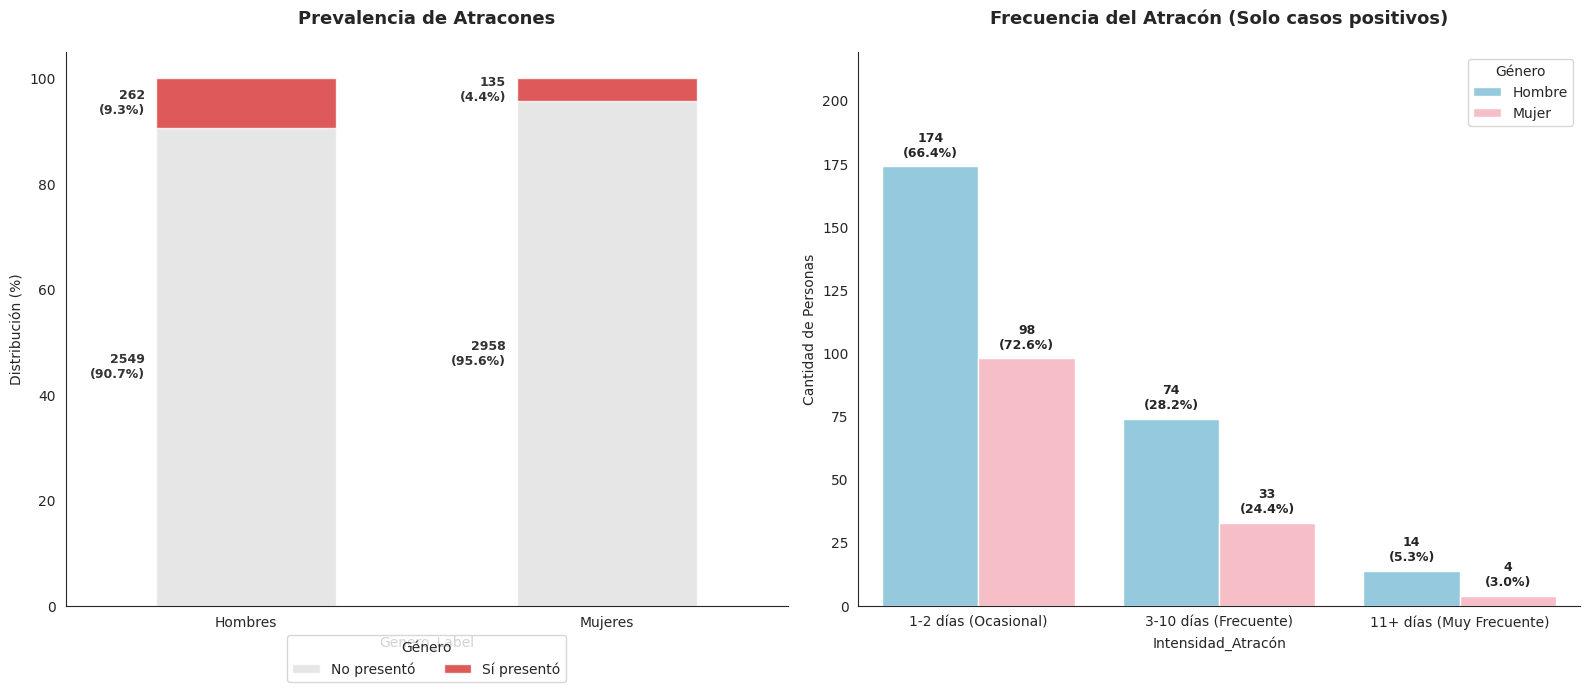

In [533]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Preparación de datos (Merge)
df_consolidado = pd.merge(df_demo, df_alq[['SEQN', 'Dias_Con_+4_5_Tragos_En_2hrs']], on='SEQN', how='inner')
df_consolidado['Genero_Label'] = df_consolidado['Genero'].map({1: "Hombre", 2: "Mujer"})

# 2. Categorización
def categorizar_atracón(dias):
    if dias == 0: return "0 días (Nunca)"
    if 1 <= dias <= 2: return "1-2 días (Ocasional)"
    if 3 <= dias <= 10: return "3-10 días (Frecuente)"
    return "11+ días (Muy Frecuente)"

df_consolidado['Intensidad_Atracón'] = df_consolidado['Dias_Con_+4_5_Tragos_En_2hrs'].apply(categorizar_atracón)
df_consolidado['Es_Binge'] = df_consolidado['Dias_Con_+4_5_Tragos_En_2hrs'] > 0

# 3. Configuración de la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("white")

# --- GRÁFICO 1: Prevalencia (%) ---
prevalencia = df_consolidado.groupby(['Genero_Label', 'Es_Binge']).size().unstack(fill_value=0)
prevalencia_pct = prevalencia.div(prevalencia.sum(axis=1), axis=0) * 100

# Forzamos orden de las barras: [0: No, 1: Sí]
prevalencia_pct.plot(kind='bar', stacked=True, ax=ax1, color=['#e0e0e0', '#d63031'], alpha=0.8)

# ANOTACIONES EN GRÁFICO 1 (A la IZQUIERDA)
for i, genero in enumerate(prevalencia_pct.index):
    cum_height = 0
    for j, col in enumerate(prevalencia_pct.columns):
        height = prevalencia_pct.loc[genero, col]
        cantidad = prevalencia.loc[genero, col]
        
        # Posición: x es el índice (0 o 1), y es el centro del segmento
        y_pos = cum_height + (height / 2)
        x_pos = i - 0.28 # Ajuste a la izquierda de la barra
        
        ax1.text(x_pos, y_pos, f'{int(cantidad)}\n({height:.1f}%)', 
                 ha='right', va='center', fontweight='bold', fontsize=9, color='#333')
        cum_height += height

ax1.set_title('Prevalencia de Atracones', fontsize=13, fontweight='bold', pad=20)
ax1.set_ylabel('Distribución (%)')
ax1.set_xticklabels(["Hombres", "Mujeres"], rotation=0)
ax1.legend(['No presentó', 'Sí presentó'], loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2,title="Género")

# --- GRÁFICO 2: Intensidad ---
df_si = df_consolidado[df_consolidado['Dias_Con_+4_5_Tragos_En_2hrs'] > 0]
orden_intensidad = ["1-2 días (Ocasional)", "3-10 días (Frecuente)", "11+ días (Muy Frecuente)"]
totales_por_genero = df_si['Genero_Label'].value_counts()

# Dibujamos el countplot con hue_order explícito para evitar confusiones
ax2 = sns.countplot(
    data=df_si, 
    x='Intensidad_Atracón', 
    hue='Genero_Label', 
    hue_order=["Hombre", "Mujer"],
    order=orden_intensidad,
    palette=["skyblue", "lightpink"],
    ax=ax2
)

# ANOTACIONES EN GRÁFICO 2 (Cantidad y % real)
# Iteramos por los contenedores de Seaborn (cada uno es un género)
for i, container in enumerate(ax2.containers):
    genero = "Hombre" if i == 0 else "Mujer"
    total_g = totales_por_genero[genero]
    
    # Añadimos la etiqueta a cada barra del contenedor
    labels = [f'{int(v.get_height())}\n({(v.get_height()/total_g*100):.1f}%)' if v.get_height() > 0 else '' for v in container]
    ax2.bar_label(container, labels=labels, padding=5, fontweight='bold', fontsize=9)

ax2.set_title('Frecuencia del Atracón (Solo casos positivos)', fontsize=13, fontweight='bold', pad=20)
ax2.set_ylabel('Cantidad de Personas')
ax2.set_ylim(0, ax2.get_ylim()[1] * 1.2)
ax2.legend(title="Género")

sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_338207/760637542.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="Reds", alpha=0.8)


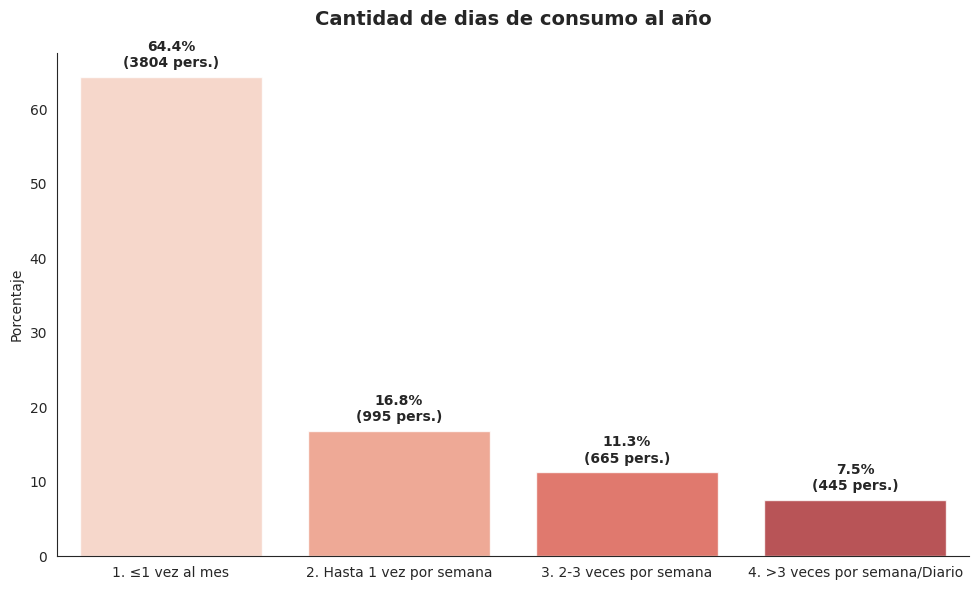

In [534]:
# 1. Definimos categorías de riesgo basadas en la frecuencia anual
def nivel_exposicion(dias):
    if dias <= 12: return "1. ≤1 vez al mes"
    if dias <= 52: return "2. Hasta 1 vez por semana"
    if dias <= 156: return "3. 2-3 veces por semana"
    return "4. >3 veces por semana/Diario"

df_alq['Nivel_Cronicidad'] = df_alq['Dias_Consumo_Anual'].apply(nivel_exposicion)

# 2. Visualización: Gráfico de Barras con Porcentajes
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Calculamos porcentajes para que sea comparable
counts = df_alq['Nivel_Cronicidad'].value_counts(normalize=True).sort_index() * 100

ax = sns.barplot(x=counts.index, y=counts.values, palette="Reds", alpha=0.8)

# Añadimos las etiquetas de porcentaje y cantidad real
for i, p in enumerate(ax.patches):
    count_real = df_alq['Nivel_Cronicidad'].value_counts().sort_index().values[i]
    ax.annotate(f'{p.get_height():.1f}%\n({count_real} pers.)', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontweight='bold')

plt.title('Cantidad de dias de consumo al año', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Porcentaje')
plt.xlabel('')
sns.despine()
plt.tight_layout()
plt.show()

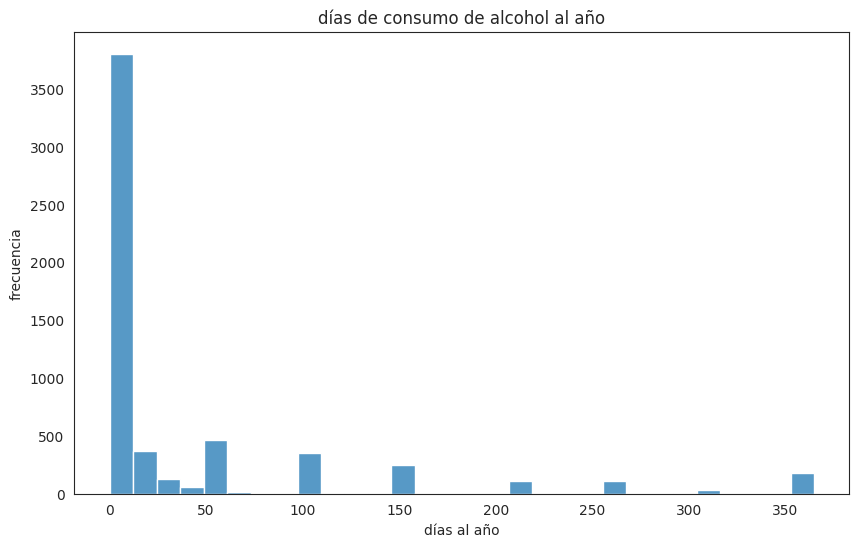

In [535]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Usando seaborn para el histograma
sns.histplot(df_alq['Dias_Consumo_Anual'], bins=30, kde=False)

# La magia ocurre aquí:

plt.title('días de consumo de alcohol al año')
plt.xlabel('días al año')
plt.ylabel('frecuencia')
plt.show()

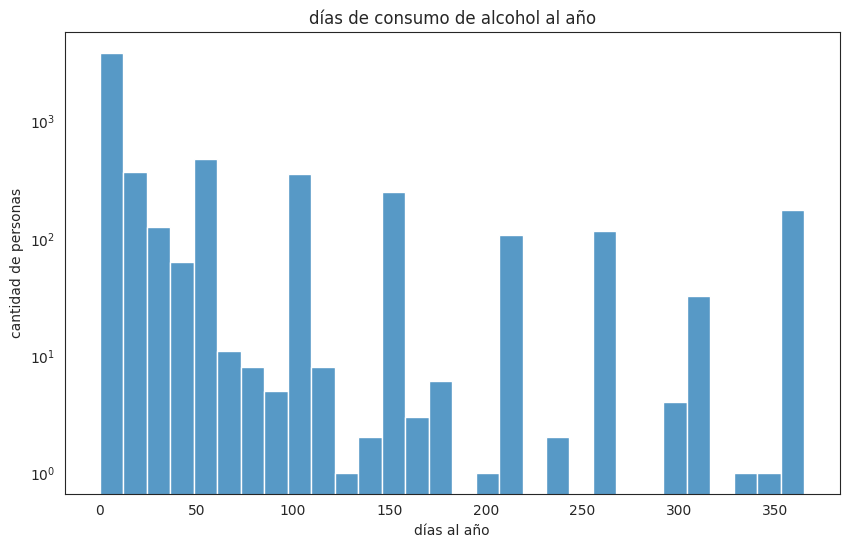

In [536]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_alq['Dias_Consumo_Anual'], bins=30, kde=False)

plt.yscale('log')

plt.title('días de consumo de alcohol al año')
plt.xlabel('días al año')
plt.ylabel('cantidad de personas')
plt.show()


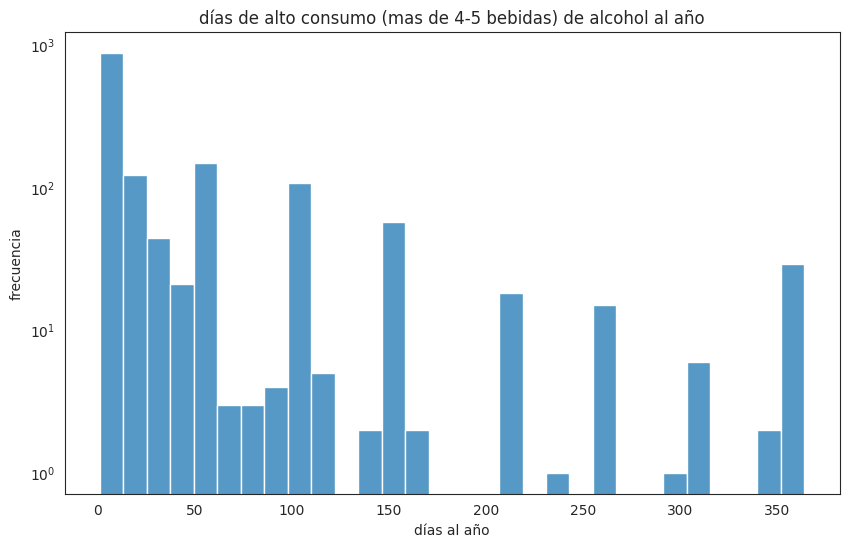

In [537]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Usando seaborn para el histograma
df_altos_bebedores = df_alq[df_alq['Dias_Alto_Consumo_Anual'] > 0].copy()
sns.histplot(df_altos_bebedores['Dias_Alto_Consumo_Anual'], bins=30, kde=False)

plt.yscale('log')

plt.title('días de alto consumo (mas de 4-5 bebidas) de alcohol al año')
plt.xlabel('días al año')
plt.ylabel('frecuencia')
plt.show()

/tmp/ipykernel_338207/4148892565.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="Reds", alpha=0.8)


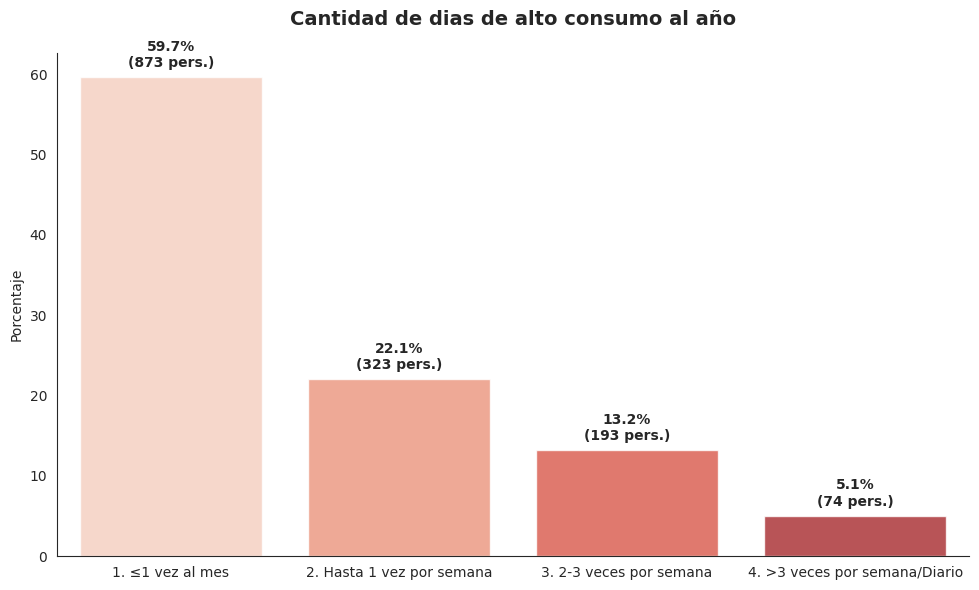

In [538]:
# 1. Definimos categorías de riesgo basadas en la frecuencia anual
def nivel_exposicion(dias):
    if dias <= 12: return "1. ≤1 vez al mes"
    if dias <= 52: return "2. Hasta 1 vez por semana"
    if dias <= 156: return "3. 2-3 veces por semana"
    return "4. >3 veces por semana/Diario"

df_altos_bebedores['Nivel_Cronicidad'] = df_altos_bebedores['Dias_Alto_Consumo_Anual'].apply(nivel_exposicion)

# 2. Visualización: Gráfico de Barras con Porcentajes
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Calculamos porcentajes para que sea comparable
counts = df_altos_bebedores['Nivel_Cronicidad'].value_counts(normalize=True).sort_index() * 100

ax = sns.barplot(x=counts.index, y=counts.values, palette="Reds", alpha=0.8)

# Añadimos las etiquetas de porcentaje y cantidad real
for i, p in enumerate(ax.patches):
    count_real = df_altos_bebedores['Nivel_Cronicidad'].value_counts().sort_index().values[i]
    ax.annotate(f'{p.get_height():.1f}%\n({count_real} pers.)', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), 
                textcoords='offset points', fontweight='bold')

plt.title('Cantidad de dias de alto consumo al año', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Porcentaje')
plt.xlabel('')
sns.despine()
plt.tight_layout()
plt.show()

### multivariable


In [539]:
df_final = pd.merge(df_dpq, df_alq, on='SEQN', how='inner')

In [540]:
df_alq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5909 entries, 0 to 5908
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SEQN                          5909 non-null   float64
 1   Promedio_Tragos_Dia           5909 non-null   float64
 2   Dias_Con_+4_5_Tragos_En_2hrs  5909 non-null   float64
 3   Consumio_Alcohol              5909 non-null   bool   
 4   Dias_Consumo_Anual            5909 non-null   float64
 5   Dias_Alto_Consumo_Anual       5909 non-null   float64
 6   Nivel_Cronicidad              5909 non-null   object 
dtypes: bool(1), float64(5), object(1)
memory usage: 282.9+ KB


Promedio de depresión por grupo:
Consumio_Alcohol
False    3.536954
True     3.191823
Name: score_depresion, dtype: float64


/tmp/ipykernel_338207/1840375408.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


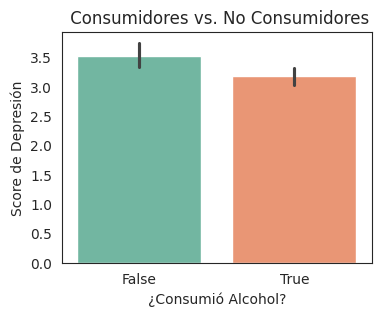

In [541]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos el promedio exacto por grupo
promedios = df_final.groupby('Consumio_Alcohol')['score_depresion'].mean()

print("Promedio de depresión por grupo:")
print(promedios)

plt.figure(figsize=(4, 3))
sns.barplot(
    data=df_final, 
    x='Consumio_Alcohol', 
    y='score_depresion', 
    palette='Set2'
)

plt.title(' Consumidores vs. No Consumidores')
plt.xlabel('¿Consumió Alcohol?')
plt.ylabel('Score de Depresión')
plt.show()

Promedio de depresión por grupo:
Consumio_Alcohol
False    3.536954
True     3.191823
Name: score_depresion, dtype: float64


/tmp/ipykernel_338207/1268212265.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


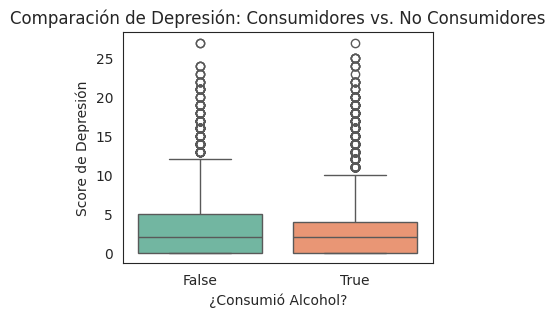

In [542]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos el promedio exacto por grupo
promedios = df_final.groupby('Consumio_Alcohol')['score_depresion'].mean()

print("Promedio de depresión por grupo:")
print(promedios)

plt.figure(figsize=(4, 3))
sns.boxplot(
    data=df_final, 
    x='Consumio_Alcohol', 
    y='score_depresion', 
    palette='Set2'
)

plt.title('Comparación de Depresión: Consumidores vs. No Consumidores')
plt.xlabel('¿Consumió Alcohol?')
plt.ylabel('Score de Depresión')
plt.show()

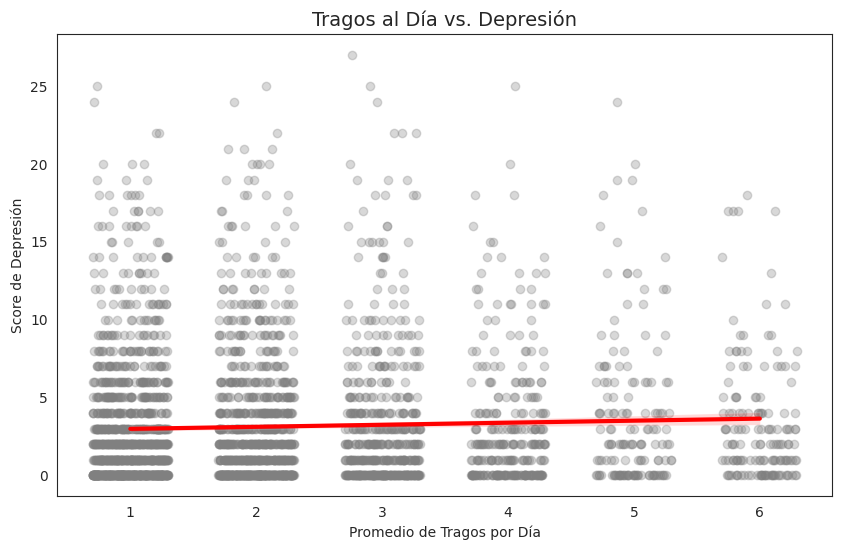

Se eliminaron 179 registros considerados extremos.


In [543]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos primero a los que consumen alcohol (> 0)
df_con_tragos = df_final[df_final['Promedio_Tragos_Dia'] > 0].copy()

# 2. Calculamos el filtro IQR para los tragos
Q1 = df_con_tragos['Promedio_Tragos_Dia'].quantile(0.25)
Q3 = df_con_tragos['Promedio_Tragos_Dia'].quantile(0.75)
IQR = Q3 - Q1

# Definimos el límite superior (1.5 es el estándar, puedes usar 2 o 3 si quieres ser menos estricto)
limite_superior = Q3 + 1.5 * IQR

# 3. Filtramos el dataframe
df_limpio = df_con_tragos[df_con_tragos['Promedio_Tragos_Dia'] <= limite_superior]

# 4. Graficamos con el mismo "espíritu"
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_limpio, 
    x='Promedio_Tragos_Dia', 
    y='score_depresion', 
    x_jitter=0.3,               # Aumenté un poco el jitter para mejor visibilidad
    scatter_kws={'alpha':0.3, 'color':'gray'}, 
    line_kws={'color':'red', 'linewidth':3}
)

plt.title(f'Tragos al Día vs. Depresión', fontsize=14)
plt.xlabel('Promedio de Tragos por Día')
plt.ylabel('Score de Depresión')
plt.show()

print(f"Se eliminaron {len(df_con_tragos) - len(df_limpio)} registros considerados extremos.")

/tmp/ipykernel_338207/1451897407.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


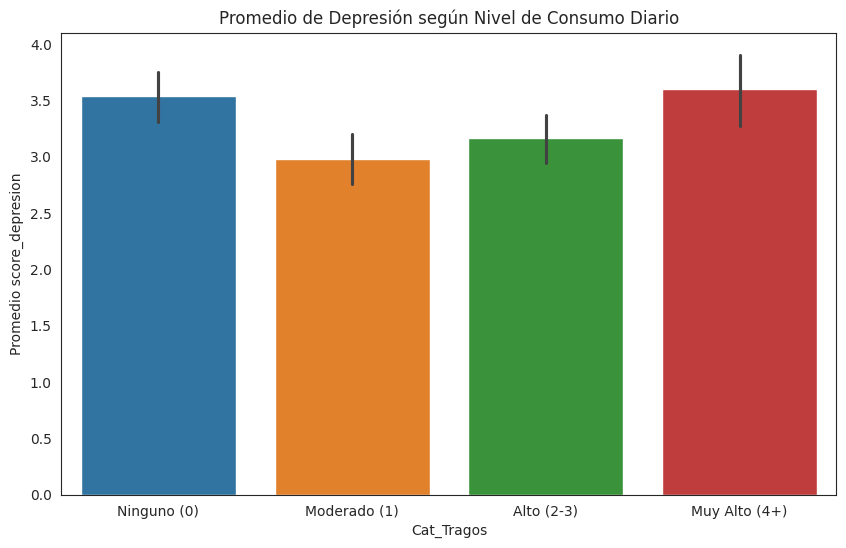

In [544]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos categorías para 'Promedio de Tragos'
bins_tragos = [-1, 0, 1, 3, 25]
labels_tragos = ['Ninguno (0)', 'Moderado (1)', 'Alto (2-3)', 'Muy Alto (4+)']
df_final['Cat_Tragos'] = pd.cut(df_final['Promedio_Tragos_Dia'], bins=bins_tragos, labels=labels_tragos)

# 2. Graficamos el promedio (Media)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_final, 
    x='Cat_Tragos', 
    y='score_depresion', 
    palette='tab10',
    errorbar=('ci', 95) # Muestra el margen de error del promedio
)
plt.title('Promedio de Depresión según Nivel de Consumo Diario')
plt.ylabel('Promedio score_depresion')
plt.show()

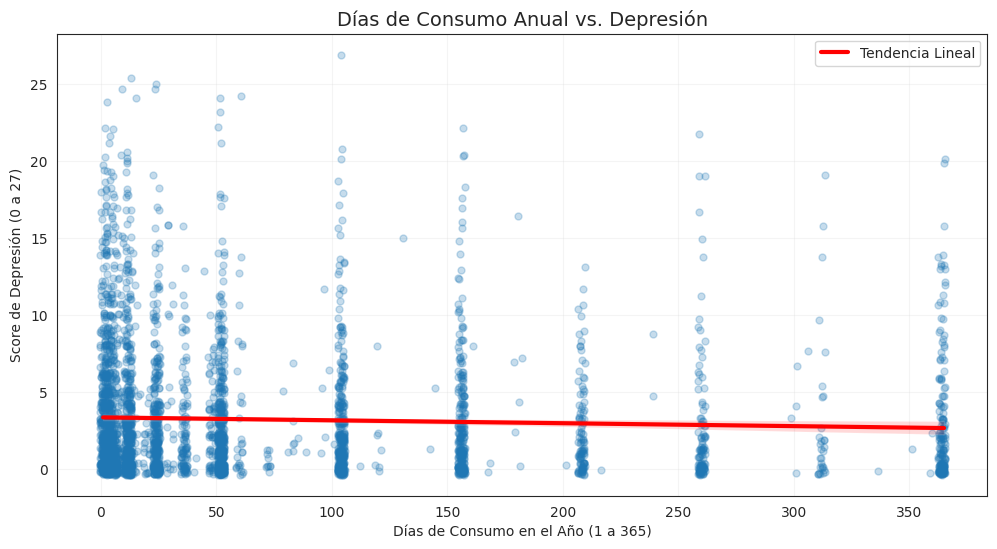

Total de personas analizadas en este gráfico: 3571


In [545]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos únicamente para excluir a los que no consumen (0 días)
df_crudo = df_final[df_final['Dias_Consumo_Anual'] > 0].copy()

# 2. Creamos el scatter plot con regplot para ver la tendencia general
plt.figure(figsize=(12, 6))

sns.regplot(
    data=df_crudo, 
    x='Dias_Consumo_Anual', 
    y='score_depresion',
    x_jitter=1.5,          # Movimiento mínimo para romper las columnas rígidas
    y_jitter=0.4,          # Movimiento mínimo vertical para ver la densidad
    scatter_kws={'alpha':0.25,  's':25}, 
    line_kws={'color':'red', 'linewidth':3, 'label': 'Tendencia Lineal'}
)

# 3. Estética del gráfico
plt.title('Días de Consumo Anual vs. Depresión', fontsize=14)
plt.xlabel('Días de Consumo en el Año (1 a 365)')
plt.ylabel('Score de Depresión (0 a 27)')
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

print(f"Total de personas analizadas en este gráfico: {len(df_crudo)}")

/tmp/ipykernel_338207/4261697938.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


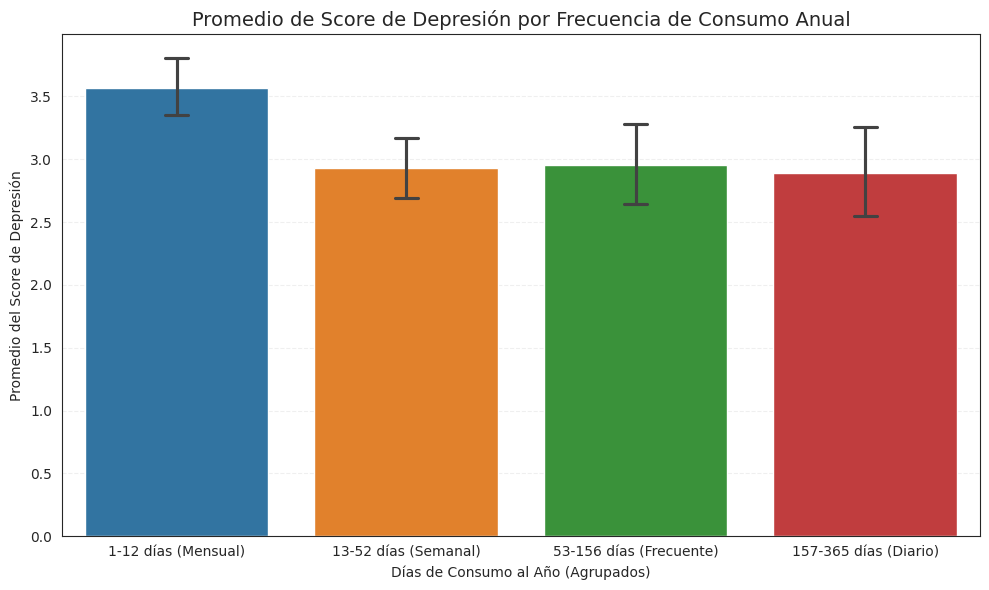

Estadísticas por categoría de consumo:
Frecuencia_Consumo
1-12 días (Mensual)        3.569680
13-52 días (Semanal)       2.928499
53-156 días (Frecuente)    2.951807
157-365 días (Diario)      2.887133
Name: score_depresion, dtype: float64
Resumen estadístico por categoría:
        Frecuencia_Consumo      mean  count
0      1-12 días (Mensual)  3.569680   1471
1     13-52 días (Semanal)  2.928499    993
2  53-156 días (Frecuente)  2.951807    664
3    157-365 días (Diario)  2.887133    443


/tmp/ipykernel_338207/4261697938.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_final.groupby('Frecuencia_Consumo')['score_depresion'].mean())
/tmp/ipykernel_338207/4261697938.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen = df_final.groupby('Frecuencia_Consumo')['score_depresion'].agg(['mean', 'count']).reset_index()


In [546]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos los rangos (Bins) para los días de consumo anual
# Definimos puntos de corte lógicos: 
# 1-12 (una vez al mes), 13-52 (una vez por semana), 53-156 (frecuente), 157-365 (diario)
bins = [0, 12, 52, 156, 365]
labels = ['1-12 días (Mensual)', '13-52 días (Semanal)', '53-156 días (Frecuente)', '157-365 días (Diario)']

# Creamos la nueva columna de categorías
df_final['Frecuencia_Consumo'] = pd.cut(df_final['Dias_Consumo_Anual'], bins=bins, labels=labels)

# 2. Graficamos el Promedio por categoría
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_final, 
    x='Frecuencia_Consumo', 
    y='score_depresion', 
    palette='tab10',
    errorbar=('ci', 95), # Muestra el intervalo de confianza del promedio
    capsize=0.1
)

# 3. Estética
plt.title('Promedio de Score de Depresión por Frecuencia de Consumo Anual', fontsize=14)
plt.xlabel('Días de Consumo al Año (Agrupados)')
plt.ylabel('Promedio del Score de Depresión')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Corroboración con Pandas
print("Estadísticas por categoría de consumo:")
print(df_final.groupby('Frecuencia_Consumo')['score_depresion'].mean())
resumen = df_final.groupby('Frecuencia_Consumo')['score_depresion'].agg(['mean', 'count']).reset_index()
print("Resumen estadístico por categoría:")
print(resumen)

/tmp/ipykernel_338207/4257253150.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


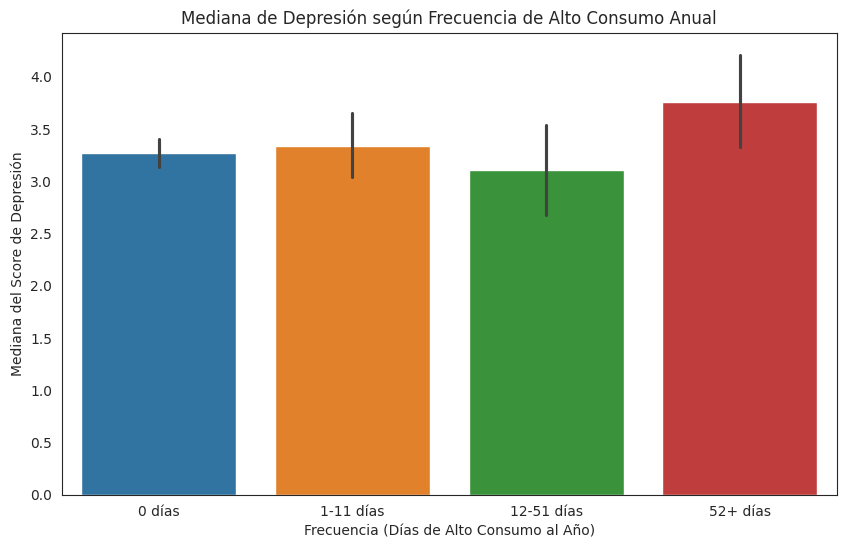

/tmp/ipykernel_338207/4257253150.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen = df_final.groupby('Categoria_Alto_Consumo')['score_depresion'].agg(['mean', 'count']).reset_index()


Resumen estadístico por categoría:
  Categoria_Alto_Consumo      mean  count
0                 0 días  3.269300   3899
1              1-11 días  3.339096    752
2             12-51 días  3.111111    306
3               52+ días  3.762500    400


In [547]:
import pandas as pd
import numpy as np

# Creamos rangos: 0 días, 1 a 11 (menos de 1 al mes), 12 a 51 (mensual), 52+ (semanal+)
bins = [-1, 0, 11, 51, 365]
etiquetas = ['0 días', '1-11 días', '12-51 días', '52+ días']
df_final['Categoria_Alto_Consumo'] = pd.cut(df_final['Dias_Alto_Consumo_Anual'], bins=bins, labels=etiquetas)

plt.figure(figsize=(10, 6))
# Usamos la mediana (np.median) por lo que discutimos antes sobre los valores extremos
sns.barplot(
    data=df_final, 
    x='Categoria_Alto_Consumo', 
    y='score_depresion', 
    estimator=np.mean,
    palette='tab10',
    errorbar=('ci', 95)
)
plt.title('Mediana de Depresión según Frecuencia de Alto Consumo Anual')
plt.xlabel('Frecuencia (Días de Alto Consumo al Año)')
plt.ylabel('Mediana del Score de Depresión')
plt.show()
resumen = df_final.groupby('Categoria_Alto_Consumo')['score_depresion'].agg(['mean', 'count']).reset_index()
print("Resumen estadístico por categoría:")
print(resumen)

/tmp/ipykernel_338207/3787004511.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_promedio = df_final.groupby('Categoria_Binge')['score_depresion'].mean().max()
/tmp/ipykernel_338207/3787004511.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


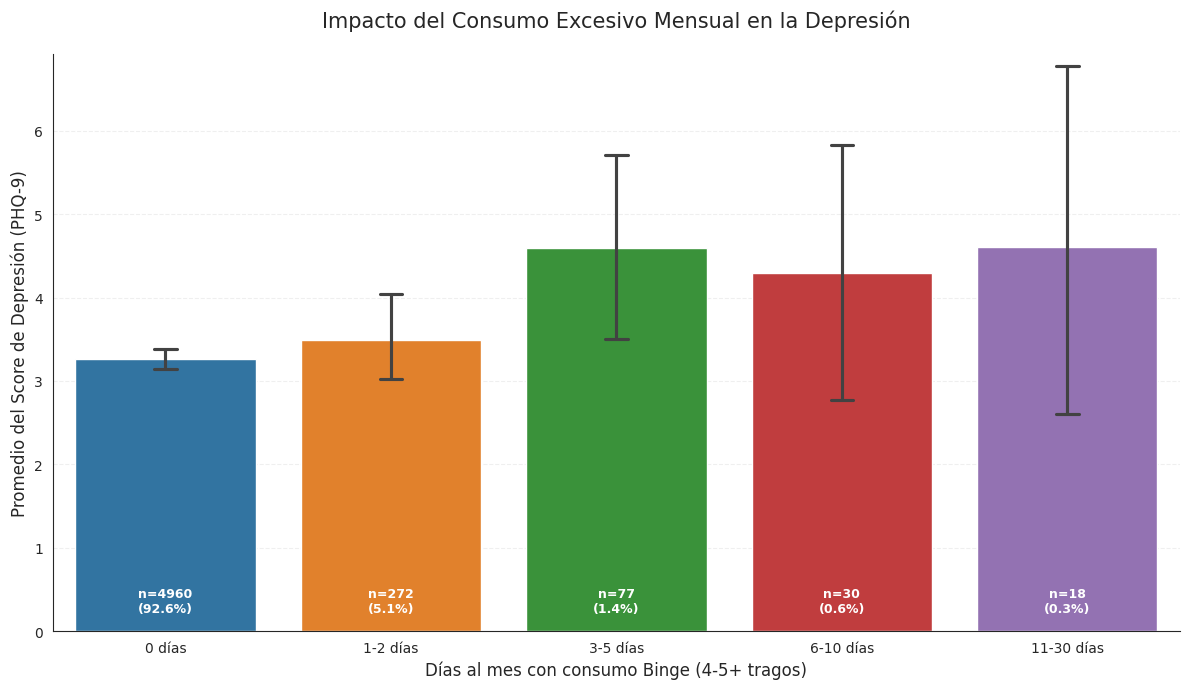

In [548]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir los cortes (bins) y etiquetas
bins_binge = [-1, 0, 2, 5, 10, 30]
labels_binge = ['0 días', '1-2 días', '3-5 días', '6-10 días', '11-30 días']

# 2. Crear la columna categórica
df_final['Categoria_Binge'] = pd.cut(
    df_final['Dias_Con_+4_5_Tragos_En_2hrs'], 
    bins=bins_binge, 
    labels=labels_binge
)

# --- CÁLCULOS PREVIOS ---
total_n = len(df_final)
conteos = df_final['Categoria_Binge'].value_counts().reindex(labels_binge).fillna(0)
labels_texto = [f'n={int(c)}\n({(c/total_n)*100:.1f}%)' for c in conteos]

# Calculamos el promedio máximo para ajustar el eje Y
max_promedio = df_final.groupby('Categoria_Binge')['score_depresion'].mean().max()

# 3. Graficar
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=df_final, 
    x='Categoria_Binge', 
    y='score_depresion', 
    palette='tab10',
    errorbar=('ci', 95),
    capsize=0.1
)

# --- ETIQUETAS EN LA PARTE DE ABAJO (BASE) ---
for i, bar in enumerate(ax.patches):
    # Colocamos el texto cerca de la base (y=0.2 o similar)
    # Si la barra es muy oscura, puedes usar color='white'
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        0.2,                                
        labels_texto[i],                   
        ha='center', 
        va='bottom', 
        fontsize=9, 
        fontweight='bold',
        color='white' # Color blanco para que resalte sobre las barras oscuras
    )

# 4. Ajuste del eje vertical al máximo
# Agregamos un 20% extra al promedio máximo para que quepan los intervalos de confianza
plt.ylim(0, max_promedio * 1.5)

# 5. Estética
plt.title('Impacto del Consumo Excesivo Mensual en la Depresión', fontsize=15, pad=20)
plt.xlabel('Días al mes con consumo Binge (4-5+ tragos)', fontsize=12)
plt.ylabel('Promedio del Score de Depresión (PHQ-9)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

## MCQ (condiciones medicas)

In [549]:
df_mcq = pd.read_csv('../data/mcq.csv')

In [550]:
df_mcq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6113 entries, 0 to 6112
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SEQN                   6113 non-null   float64
 1   problema_tiroides      6113 non-null   bool   
 2   problema_higado        6113 non-null   bool   
 3   tiene_artritis         6113 non-null   bool   
 4   tuvo_derrame_cerebral  6113 non-null   bool   
 5   tuvo_ataque_corazon    6113 non-null   bool   
 6   enfermedad_coronaria   6113 non-null   bool   
 7   tuvo_cancer            6113 non-null   bool   
 8   tiene_asma             6113 non-null   bool   
 9   tiene_sobrepeso        6113 non-null   bool   
 10  tiene_psoriasis        6113 non-null   bool   
dtypes: bool(10), float64(1)
memory usage: 107.6 KB


/tmp/ipykernel_338207/1208867733.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_resumen, x='Prevalencia_Si', y='Condición', palette='tab10')


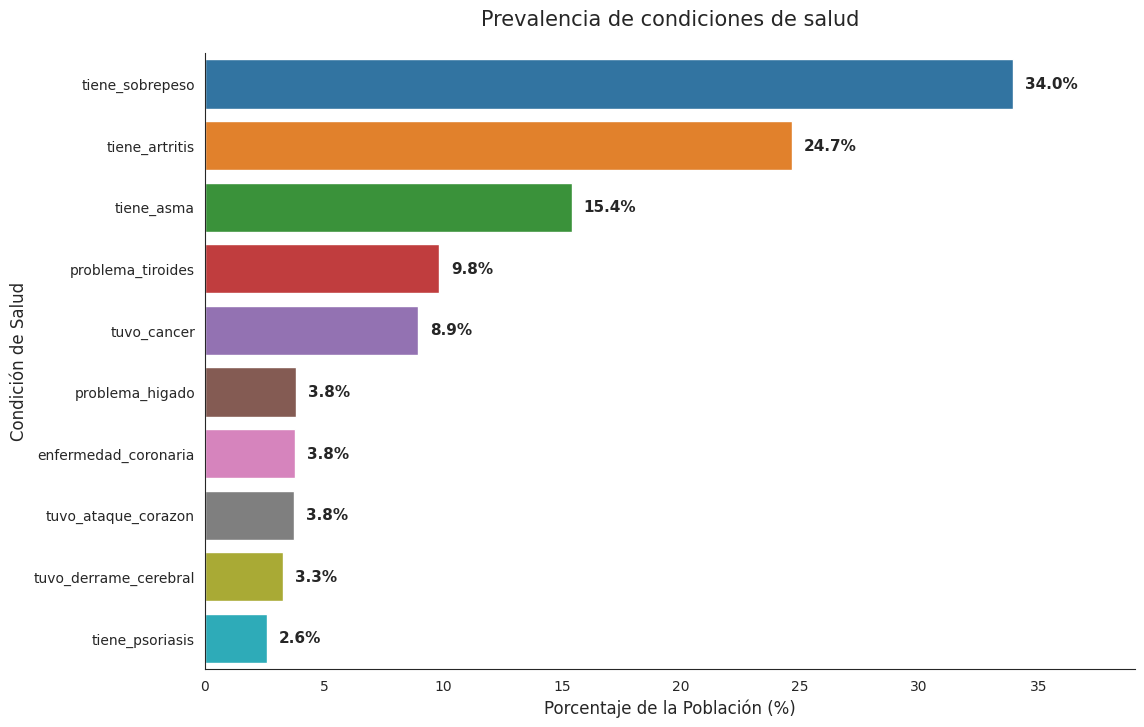

In [551]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
cols_booleanas = [
    "problema_tiroides",
    "problema_higado",
    "tiene_artritis",
    "tuvo_derrame_cerebral",
    "tuvo_ataque_corazon",
    "enfermedad_coronaria",
    "tuvo_cancer",
    "tiene_asma",
    "tiene_sobrepeso",
    "tiene_psoriasis"
]
# 1. Calcular la prevalencia de "Sí" para cada columna
prevalencias = []
for col in cols_booleanas:
    if col in df_mcq.columns:
        # Calculamos el porcentaje de True (Sí)
        porcentaje_si = df_mcq[col].mean() * 100
        prevalencias.append({'Condición': col, 'Prevalencia_Si': porcentaje_si})

# 2. Crear un DataFrame de resumen y ordenar de mayor a menor
df_resumen = pd.DataFrame(prevalencias).sort_values(by='Prevalencia_Si', ascending=False)

# 3. Graficar
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=df_resumen, x='Prevalencia_Si', y='Condición', palette='tab10')

# 4. Agregar las etiquetas de porcentaje al final de cada barra
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5, 
            p.get_y() + p.get_height() / 2, 
            f'{width:.1f}%', 
            ha='left', va='center', fontsize=11, fontweight='bold')

plt.title('Prevalencia de condiciones de salud', fontsize=15, pad=20)
plt.xlabel('Porcentaje de la Población (%)', fontsize=12)
plt.ylabel('Condición de Salud', fontsize=12)
plt.xlim(0, df_resumen['Prevalencia_Si'].max() * 1.15) # Espacio para las etiquetas
sns.despine()
plt.show()

In [552]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Unir las condiciones médicas con el score de depresión
# Usamos inner merge para quedarnos solo con los pacientes que tienen ambos datos
df_salud = pd.merge(df_final, df_mcq, on='SEQN', how='inner')

# 2. Extraer la lista de enfermedades (todas las columnas de mcq menos SEQN)
enfermedades = df_mcq.columns.drop('SEQN')

# 3. "Derretir" (Melt) el dataframe
# Esto convierte las 10 columnas booleanas en dos columnas: 'Condicion' y 'Lo_Padece'
df_melted = df_salud.melt(
    id_vars=['SEQN', 'score_depresion'], 
    value_vars=enfermedades,
    var_name='Condicion_Medica',
    value_name='Lo_Padece'
)

# Limpiamos los nombres para que el gráfico se vea profesional
df_melted['Condicion_Medica'] = df_melted['Condicion_Medica'].str.replace('_', ' ').str.title()

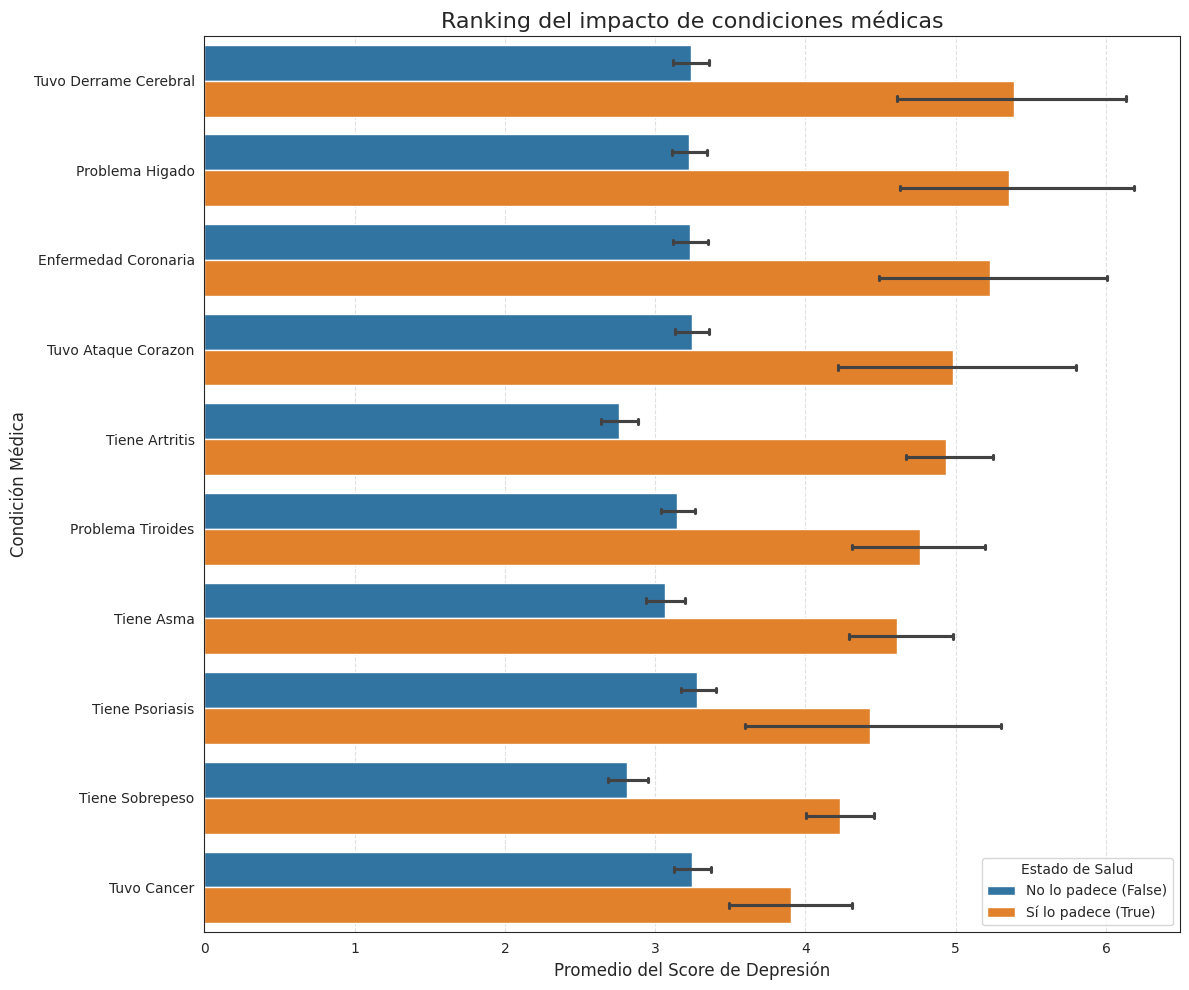

In [553]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos el orden basado en el promedio de depresión cuando 'Lo_Padece' es True
orden_enfermedades = (
    df_melted[df_melted['Lo_Padece'] == True]
    .groupby('Condicion_Medica')['score_depresion']
    .mean()
    .sort_values(ascending=False)
    .index
)

# 2. Graficamos usando el parámetro 'order'
plt.figure(figsize=(12, 10))

sns.barplot(
    data=df_melted,
    x='score_depresion',
    y='Condicion_Medica',
    hue='Lo_Padece',
    order=orden_enfermedades,  # <--- Aquí aplicamos el orden
   
    errorbar=('ci', 95),
    capsize=0.1
)

# Estética
plt.title('Ranking del impacto de condiciones médicas', fontsize=16)
plt.xlabel('Promedio del Score de Depresión', fontsize=12)
plt.ylabel('Condición Médica', fontsize=12)

# Ajustamos la leyenda
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['No lo padece (False)', 'Sí lo padece (True)'], title='Estado de Salud', loc='lower right')

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# PAQ (condicion fisica)


In [554]:
df_paq = pd.read_csv('../data/paq.csv')
df_paq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6085 entries, 0 to 6084
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   SEQN                            6085 non-null   float64
 1   minutos_sedentario_dia          6085 non-null   float64
 2   ejercicio_vigoroso_recreativo   6085 non-null   bool   
 3   ejercicio_moderado_recreativo   6085 non-null   bool   
 4   trabajo_vigoroso                6085 non-null   bool   
 5   trabajo_moderado                6085 non-null   bool   
 6   transporte_activo_bici_caminar  6084 non-null   object 
 7   horas_sedentario_dia            6085 non-null   float64
dtypes: bool(4), float64(3), object(1)
memory usage: 214.1+ KB


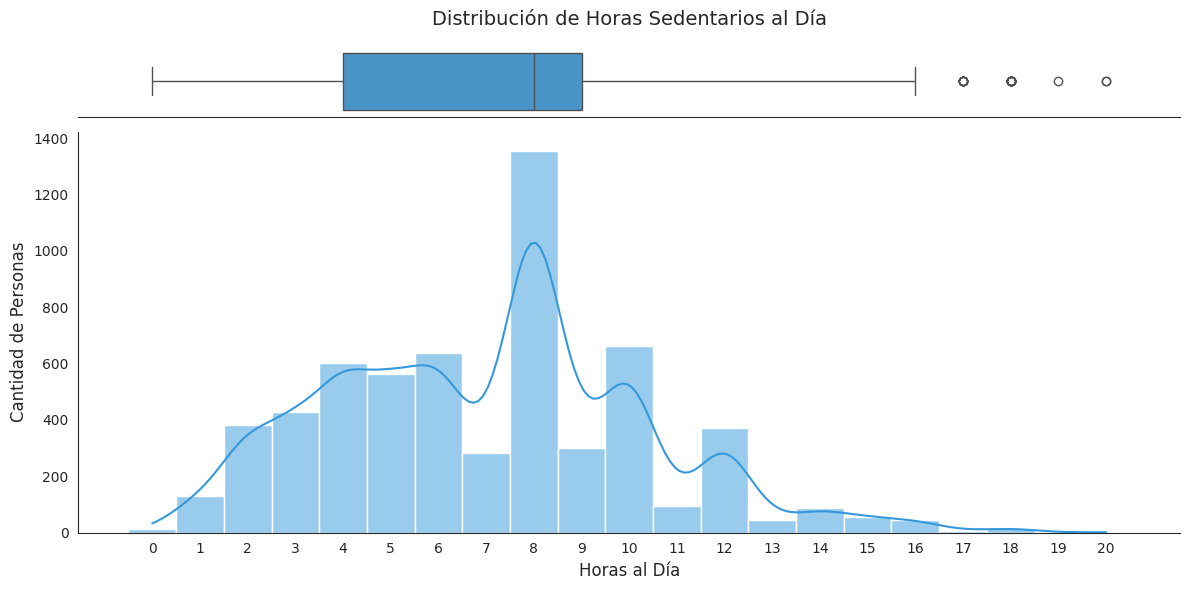

In [555]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculamos el rango de los bins para que el entero quede en el centro
# Creamos bordes que van desde -0.5, 0.5, 1.5 ... hasta max + 0.5
max_horas = int(df_paq['horas_sedentario_dia'].max())
bordes_bins = np.arange(-0.5, max_horas + 1.5, 1)

# Crear la figura
fig, (ax_box, ax_hist) = plt.subplots(
    nrows=2, 
    sharex=True, 
    figsize=(12, 6), 
    gridspec_kw={"height_ratios": (.15, .85)}
)

# 1. Boxplot
sns.boxplot(data=df_paq, x='horas_sedentario_dia', ax=ax_box, color='#3498db')
ax_box.set_title('Distribución de Horas Sedentarios al Día', fontsize=14, pad=15)
ax_box.set(xlabel='')

# 2. Histograma - AQUÍ USAMOS bordes_bins
sns.histplot(
    data=df_paq, 
    x='horas_sedentario_dia', 
    ax=ax_hist, 
    bins=bordes_bins, # <--- Usamos los bordes calculados
    kde=True, 
    color='#3498db',
    edgecolor='white'  # Añadimos un borde blanco para que se vean separadas
)

ax_hist.set_xlabel('Horas al Día', fontsize=12)
ax_hist.set_ylabel('Cantidad de Personas', fontsize=12)

# Ajustamos los ticks para que coincidan con los centros
ax_hist.set_xticks(np.arange(0, max_horas + 1, 1)) 

# Limpieza visual
sns.despine(ax=ax_hist)
sns.despine(ax=ax_box, left=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_338207/2437865768.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_resumen_act, x='Prevalencia_Si', y='Actividad', palette='tab10')


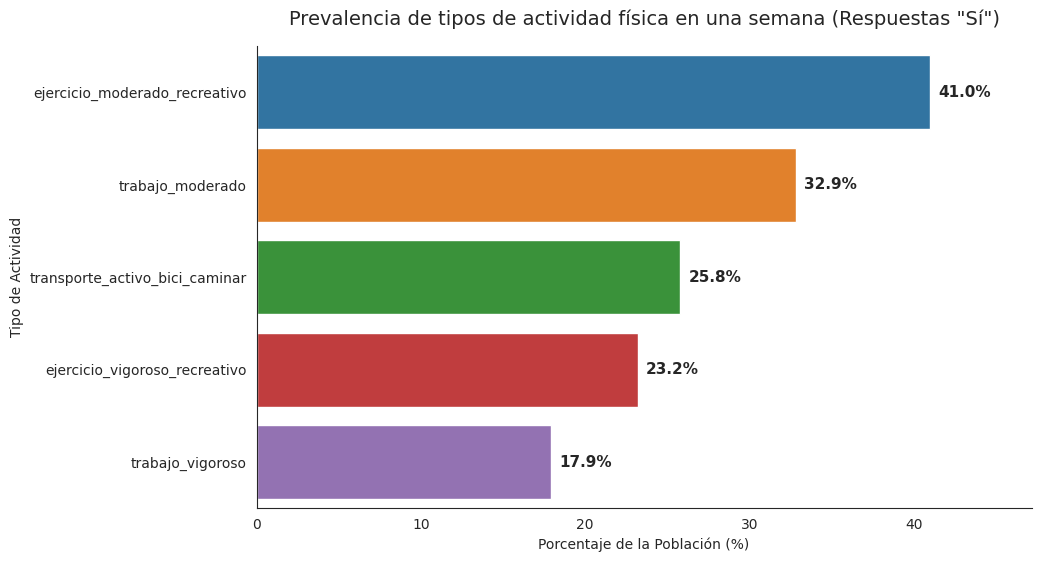

In [556]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols_actividad = [
    'ejercicio_vigoroso_recreativo', 'ejercicio_moderado_recreativo', 
    'trabajo_vigoroso', 'trabajo_moderado', 'transporte_activo_bici_caminar'
]

# Calcular la prevalencia de "Sí" (True) para cada tipo de actividad
prevalencias_act = []
for col in cols_actividad:
    if col in df_paq.columns:
        porcentaje_si = df_paq[col].mean() * 100
        prevalencias_act.append({'Actividad': col, 'Prevalencia_Si': porcentaje_si})

# Crear DataFrame y ordenar de mayor a menor
df_resumen_act = pd.DataFrame(prevalencias_act).sort_values(by='Prevalencia_Si', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_resumen_act, x='Prevalencia_Si', y='Actividad', palette='tab10')

# Etiquetas de porcentaje
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5, 
            p.get_y() + p.get_height() / 2, 
            f'{width:.1f}%', 
            ha='left', va='center', fontsize=11, fontweight='bold')

plt.title('Prevalencia de tipos de actividad física en una semana (Respuestas "Sí")', fontsize=14, pad=15)
plt.xlabel('Porcentaje de la Población (%)')
plt.ylabel('Tipo de Actividad')
plt.xlim(0, df_resumen_act['Prevalencia_Si'].max() * 1.15)
sns.despine()
plt.show()

### multivariable

In [557]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Unir Actividad Física con Depresión
df_actividad = pd.merge(df_final, df_paq, on='SEQN', how='inner')

# 2. Asegurar que 'transporte_activo_bici_caminar' sea booleano o consistente
# Si viene como 'Yes'/'No' o tiene nulos, lo estandarizamos
df_actividad['transporte_activo_bici_caminar'] = df_actividad['transporte_activo_bici_caminar'].astype(bool)

# 3. Separar las columnas cualitativas (las de Sí/No)
cols_actividad = [
    'ejercicio_vigoroso_recreativo', 'ejercicio_moderado_recreativo',
    'trabajo_vigoroso', 'trabajo_moderado', 'transporte_activo_bici_caminar'
]

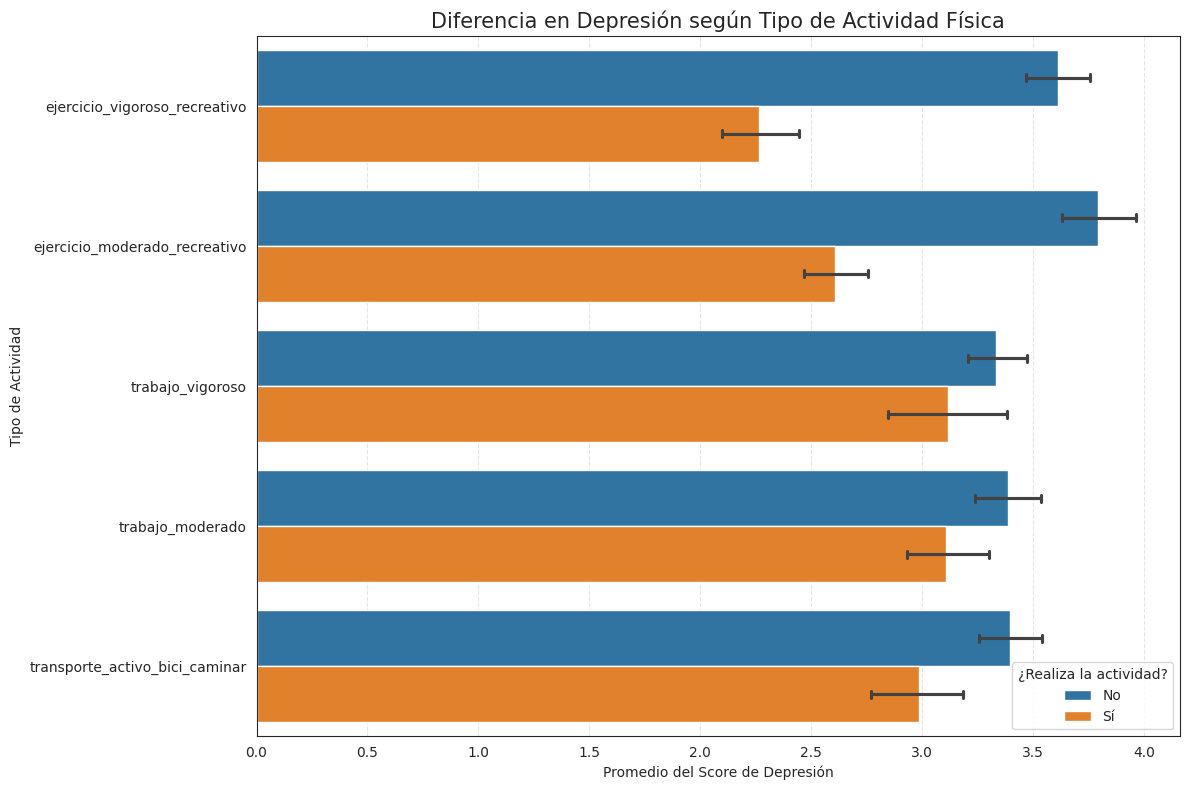

In [558]:
# "Derretimos" las variables de actividad
df_paq_melted = df_actividad.melt(
    id_vars=['SEQN', 'score_depresion'],
    value_vars=cols_actividad,
    var_name='Tipo_Actividad',
    value_name='Realiza_Actividad'
)

# 1. Aseguramos que la columna sea String para que Seaborn no tenga dudas con los colores
df_paq_melted['Realiza_Actividad'] = df_paq_melted['Realiza_Actividad'].map({True: 'Sí', False: 'No'})

plt.figure(figsize=(12, 8))

# 2. Usamos una paleta con alto contraste (Capa de colores fuertes)
sns.barplot(
    data=df_paq_melted,
    x='score_depresion',
    y='Tipo_Actividad',
    hue='Realiza_Actividad',
    hue_order=['No', 'Sí'],           # Forzamos el orden de las barras
    errorbar=('ci', 95),
    capsize=0.1
)

plt.title('Diferencia en Depresión según Tipo de Actividad Física', fontsize=15)
plt.xlabel('Promedio del Score de Depresión')
plt.ylabel('Tipo de Actividad')

# 3. Ajustamos la leyenda para que coincida con los nuevos nombres
plt.legend(title='¿Realiza la actividad?', loc='lower right')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

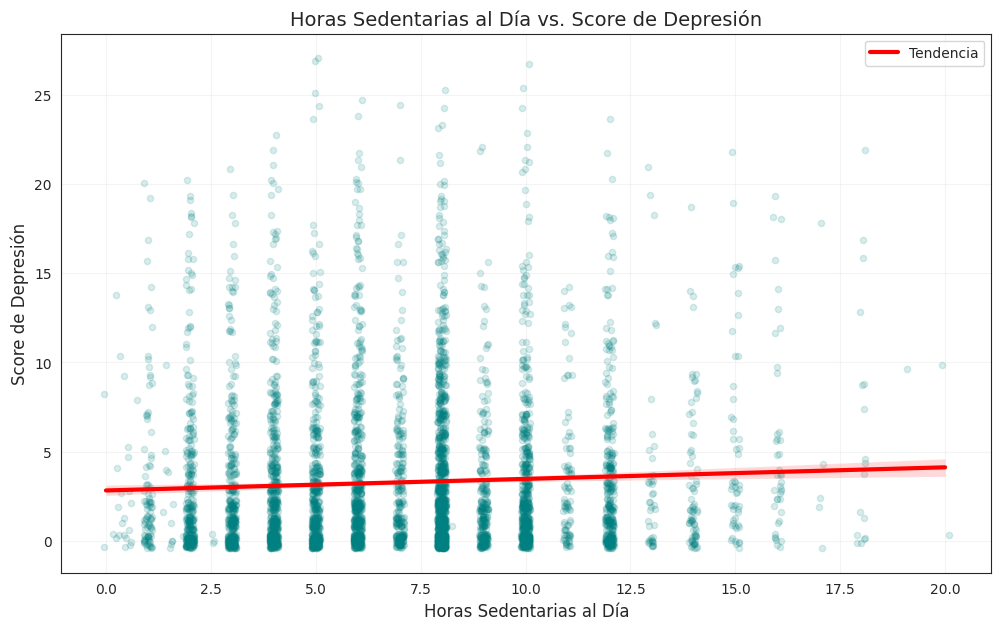

In [572]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# Usamos regplot para combinar el scatter con la línea de tendencia
sns.regplot(
    data=df_actividad,
    x='horas_sedentario_dia',
    y='score_depresion',
    x_jitter=0.1,           # Esparcimos los minutos para romper la rigidez
    y_jitter=0.4,           # Esparcimos el score de depresión para ver la densidad
    scatter_kws={'alpha': 0.15, 'color': 'teal', 's': 20}, # Transparencia para ver el solapamiento
    line_kws={'color': 'red', 'linewidth': 3, 'label': 'Tendencia'}
)

plt.title('Horas Sedentarias al Día vs. Score de Depresión', fontsize=14)
plt.xlabel('Horas Sedentarias al Día', fontsize=12)
plt.ylabel('Score de Depresión', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)

plt.show()

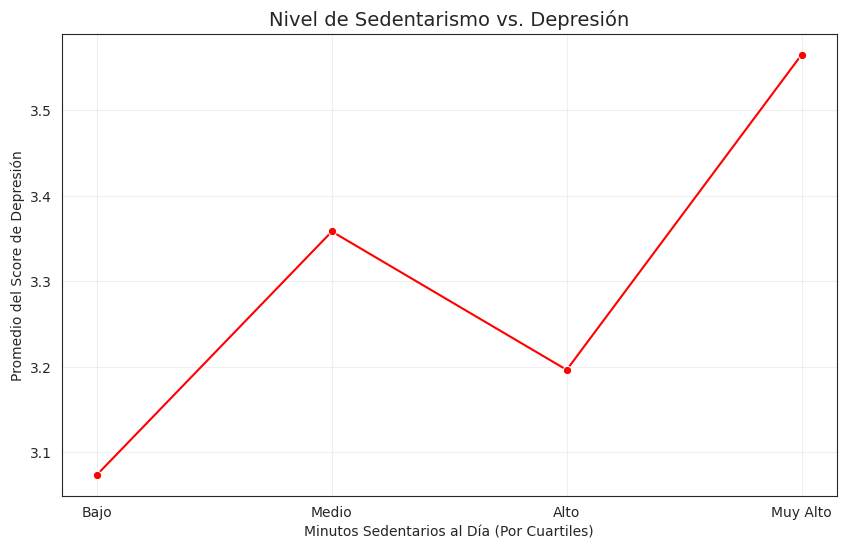

In [560]:
# Creamos 4 categorías basadas en el tiempo sentado (Cuartiles)
# Esto divide a la población en: 'Poco sentado', 'Regular', 'Bastante', 'Muy sedentario'
df_actividad['Nivel_Sedentarismo'] = pd.qcut(
    df_actividad['minutos_sedentario_dia'], 
    q=4, 
    labels=['Bajo', 'Medio', 'Alto', 'Muy Alto']
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_actividad,
    x='Nivel_Sedentarismo',
    y='score_depresion',
    marker='o',
    color='red',
    errorbar=None
)

plt.title( 'Nivel de Sedentarismo vs. Depresión', fontsize=14)
plt.xlabel('Minutos Sedentarios al Día (Por Cuartiles)')
plt.ylabel('Promedio del Score de Depresión')
plt.grid(True, alpha=0.3)
plt.show()

# whq (peso y altura)

In [561]:
df_whq = pd.read_csv('../data/whq.csv')
df_whq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5955 entries, 0 to 5954
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SEQN                   5955 non-null   float64
 1   altura_pulgadas        5955 non-null   float64
 2   peso_libras            5955 non-null   float64
 3   percibe_peso_como      5955 non-null   object 
 4   altura_cm              5955 non-null   float64
 5   intento_bajar_peso     5955 non-null   bool   
 6   conductas_riesgo_peso  5955 non-null   bool   
dtypes: bool(2), float64(4), object(1)
memory usage: 244.4+ KB


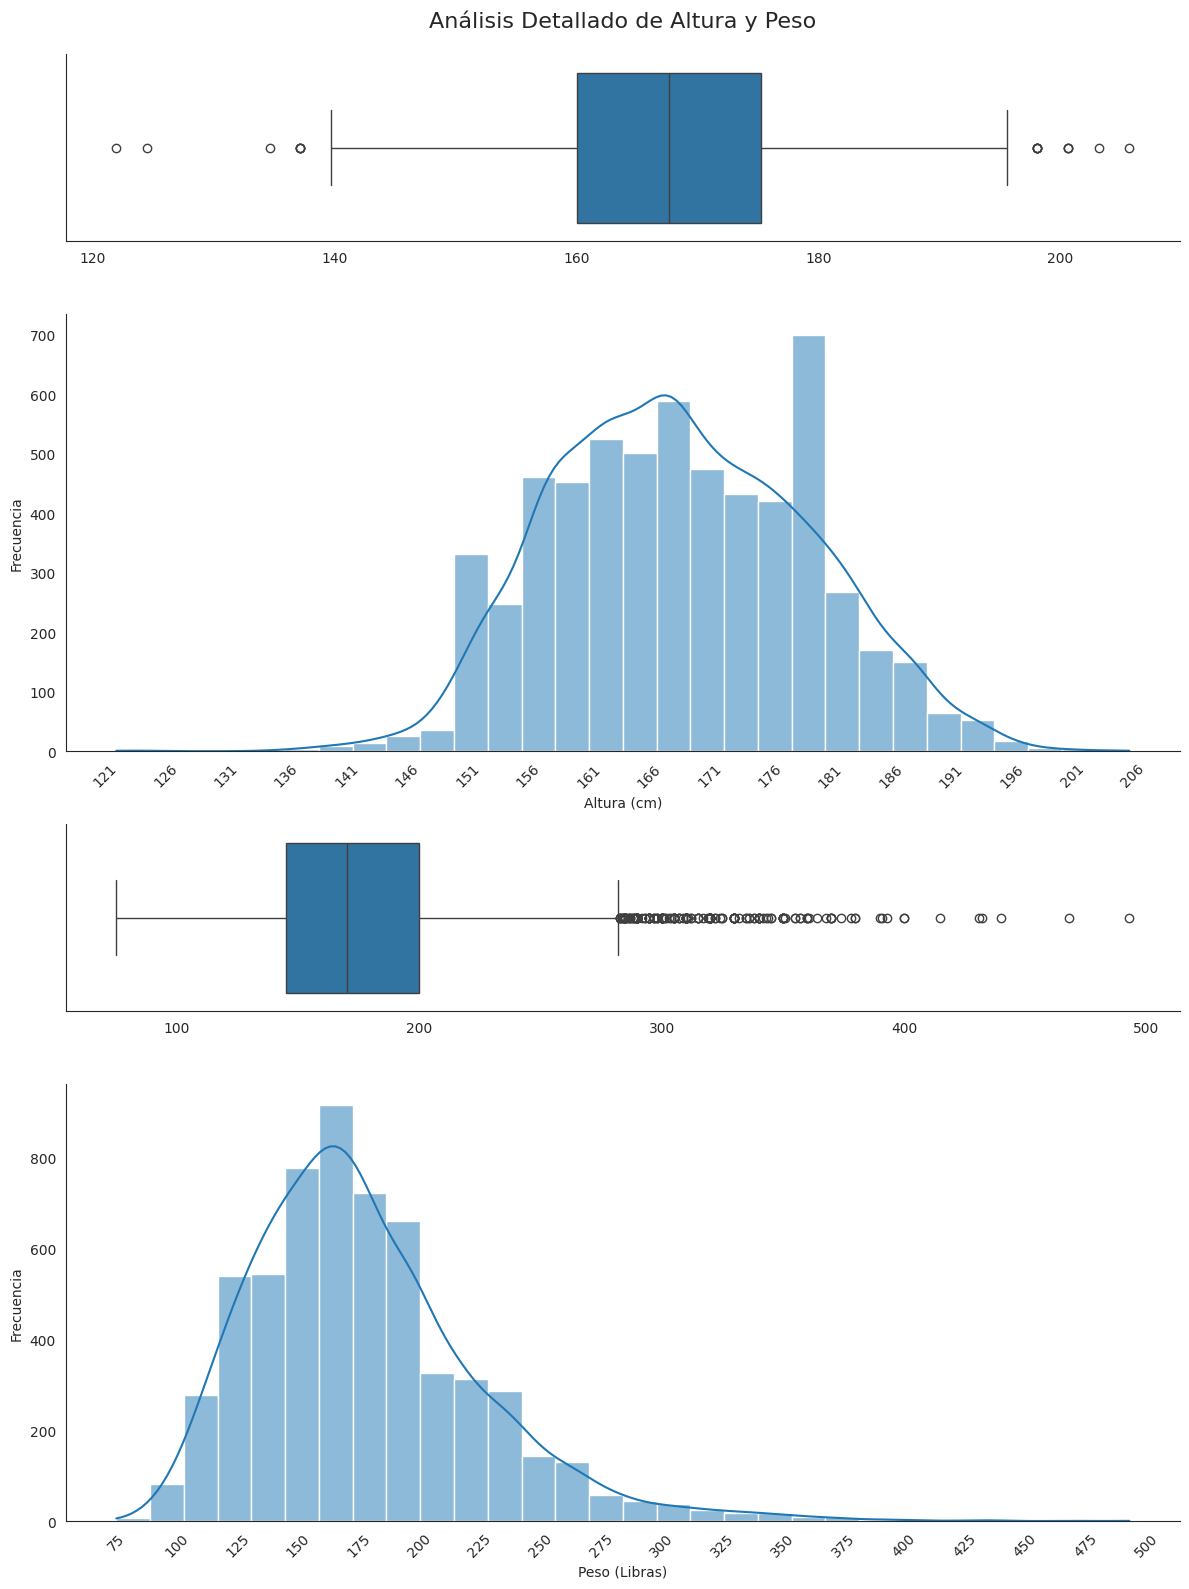

In [562]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos 4 filas (2 para Altura, 2 para Peso) y 1 sola columna
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 16), 
                         gridspec_kw={"height_ratios": (.15, .35, .15, .35)})

# --- BLOQUE 1: Altura (Pisos 0 y 1) ---
sns.boxplot(data=df_whq, x='altura_cm', ax=axes[0], )
axes[0].set_title('Análisis Detallado de Altura y Peso', fontsize=16, pad=20)
axes[0].set(xlabel='')

sns.histplot(data=df_whq, x='altura_cm', kde=True, ax=axes[1], bins=30)
axes[1].set_ylabel('Frecuencia')
axes[1].set_xlabel('Altura (cm)')

# Ajuste de Ticks para Altura (Cada 5 cm es lo más legible, puedes cambiarlo a 2)
min_h, max_h = int(df_whq['altura_cm'].min()), int(df_whq['altura_cm'].max())
axes[1].set_xticks(np.arange(min_h, max_h + 5, 5)) 

# --- BLOQUE 2: Peso (Pisos 2 y 3) ---
sns.boxplot(data=df_whq, x='peso_libras', ax=axes[2], )
axes[2].set(xlabel='')

sns.histplot(data=df_whq, x='peso_libras', kde=True, ax=axes[3],  bins=30)
axes[3].set_ylabel('Frecuencia')
axes[3].set_xlabel('Peso (Libras)')

# Ajuste de Ticks para Peso (Cada 25 lbs para no saturar)
min_p, max_p = int(df_whq['peso_libras'].min()), int(df_whq['peso_libras'].max())
axes[3].set_xticks(np.arange(min_p, max_p + 25, 25))

# Rotamos los números si vemos que se amontonan
plt.setp(axes[1].get_xticklabels(), rotation=45)
plt.setp(axes[3].get_xticklabels(), rotation=45)

# Limpieza visual
sns.despine()
plt.tight_layout()
plt.show()

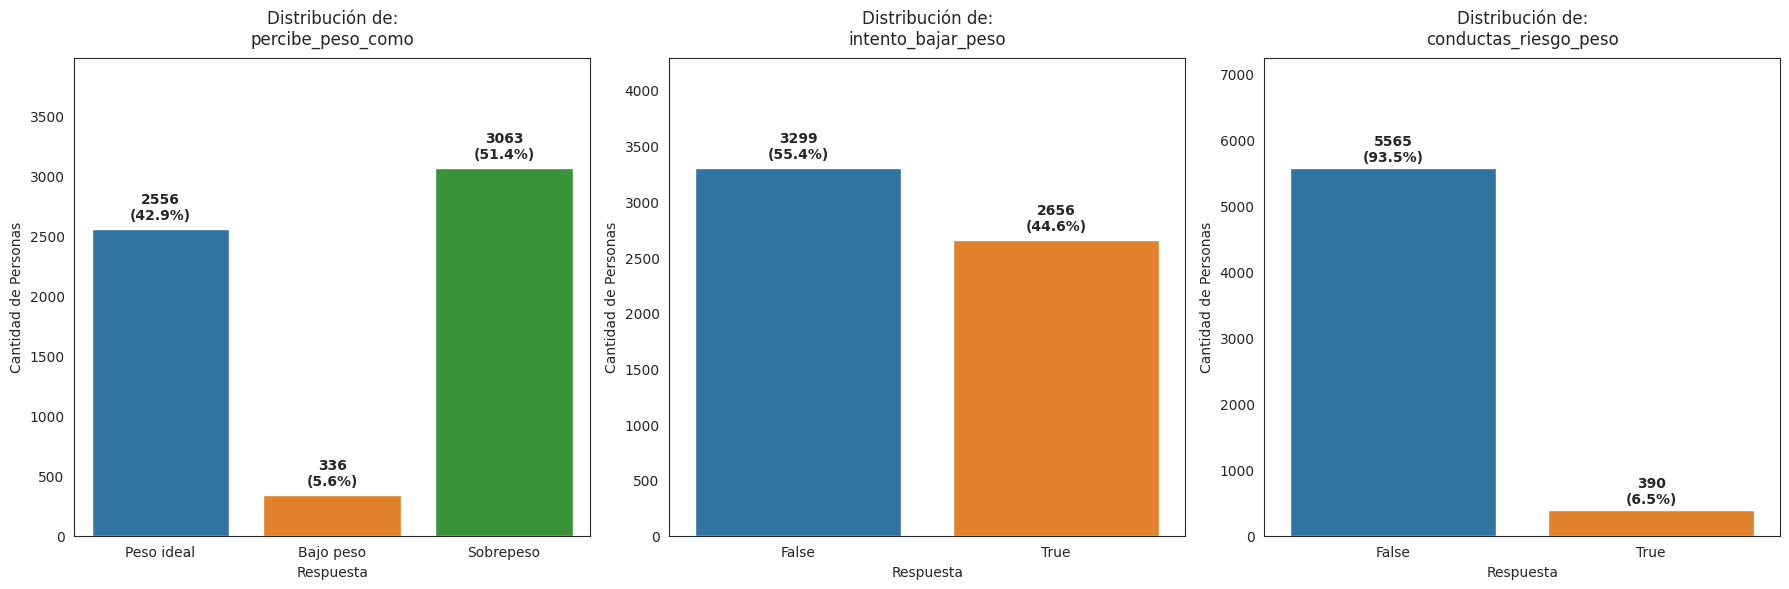

In [563]:
# Lista de variables categóricas/booleanas
cols_cat = ['percibe_peso_como', 'intento_bajar_peso', 'conductas_riesgo_peso']

# Crear figura con 3 gráficos lado a lado
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, col in enumerate(cols_cat):
    # 1. Calcular el total de valores no nulos para esta columna específica
    total = len(df_whq[col].dropna())
    
    # 2. Crear el gráfico de barras
    ax = sns.countplot(
        data=df_whq, 
        x=col, 
        hue=col,            # Asigna la variable al color
        ax=axes[i], 
        palette='tab10', 
        legend=False        # Quita la leyenda que se crea automáticamente
    )    
    axes[i].set_title(f'Distribución de:\n{col}', fontsize=12, pad=10)
    axes[i].set_ylabel('Cantidad de Personas')
    axes[i].set_xlabel('Respuesta')
    
    # 3. Agregar el conteo y el porcentaje arriba de cada barra
    for p in ax.patches:
        count = p.get_height()
        if count > 0:
            # Calcular porcentaje: (conteo / total) * 100
            percentage = f'{(100 * count / total):.1f}%'
            
            # Dibujar el texto (Conteo + Porcentaje)
            ax.text(
                p.get_x() + p.get_width() / 2., 
                count + (total * 0.01), # Offset dinámico según el volumen de datos
                f'{int(count)}\n({percentage})', 
                ha="center", va="bottom", 
                fontweight='bold', fontsize=10
            )
            
    # 4. Ajustar el límite superior para que el texto no se corte
    axes[i].set_ylim(0, df_whq[col].value_counts().max() * 1.3)

plt.tight_layout()
# plt.savefig('distribucion_con_porcentajes.png') # Recuerda usar savefig si estás en un script
plt.show()

### multivariable

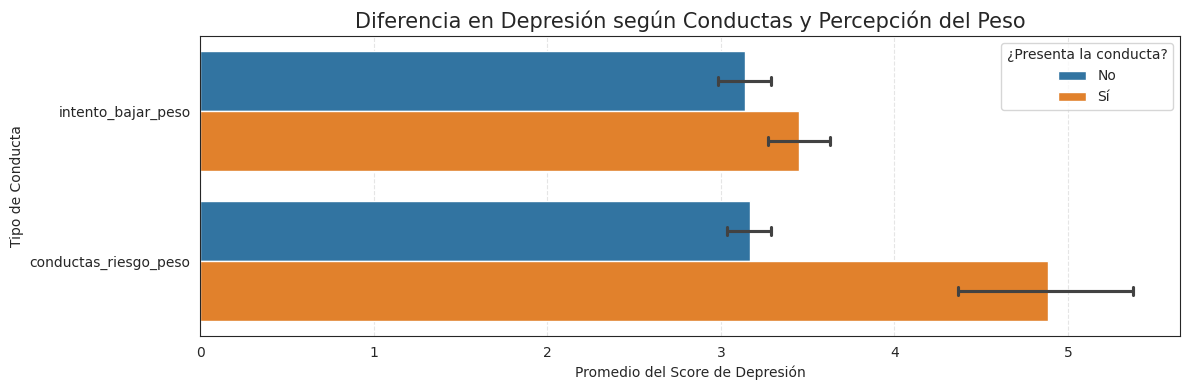

In [564]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Asumiendo que tus DataFrames se llaman df_whq y df_dpq
# Unimos los dataframes por el identificador de paciente 'SEQN'
df_merged = pd.merge(df_whq, df_dpq[['SEQN', 'score_depresion']], on='SEQN', how='inner')

# Variables booleanas que queremos analizar frente a la depresión
cols_booleanas = ['intento_bajar_peso', 'conductas_riesgo_peso']

# "Derretimos" las variables booleanas
df_bool_melted = df_merged.melt(
    id_vars=['SEQN', 'score_depresion'],
    value_vars=cols_booleanas,
    var_name='Tipo_Conducta',
    value_name='Presenta_Conducta'
)

# Aseguramos que la columna sea String para Seaborn
df_bool_melted['Presenta_Conducta'] = df_bool_melted['Presenta_Conducta'].map({True: 'Sí', False: 'No'})

# Gráfico para variables booleanas
plt.figure(figsize=(12, 4))

sns.barplot(
    data=df_bool_melted,
    x='score_depresion',
    y='Tipo_Conducta',
    hue='Presenta_Conducta',
    hue_order=['No', 'Sí'],
    errorbar=('ci', 95),
    capsize=0.1
)

plt.title('Diferencia en Depresión según Conductas y Percepción del Peso', fontsize=15)
plt.xlabel('Promedio del Score de Depresión')
plt.ylabel('Tipo de Conducta')
plt.legend(title='¿Presenta la conducta?', loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

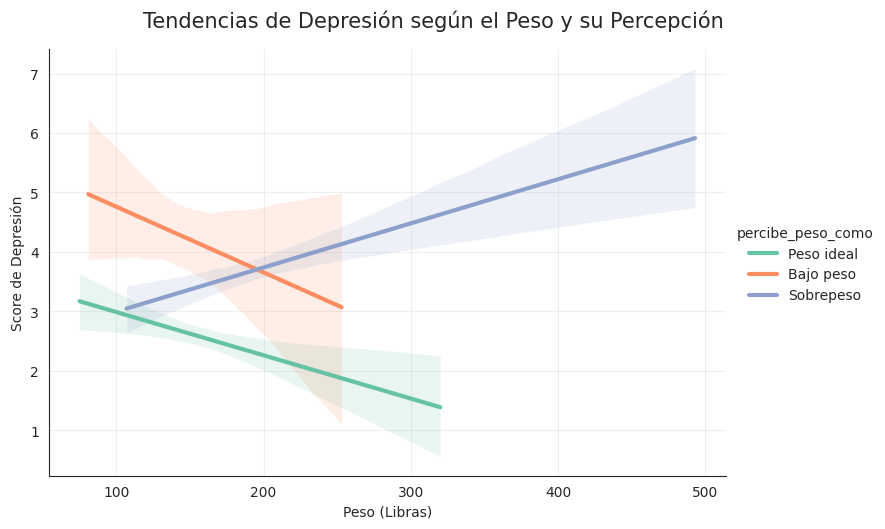

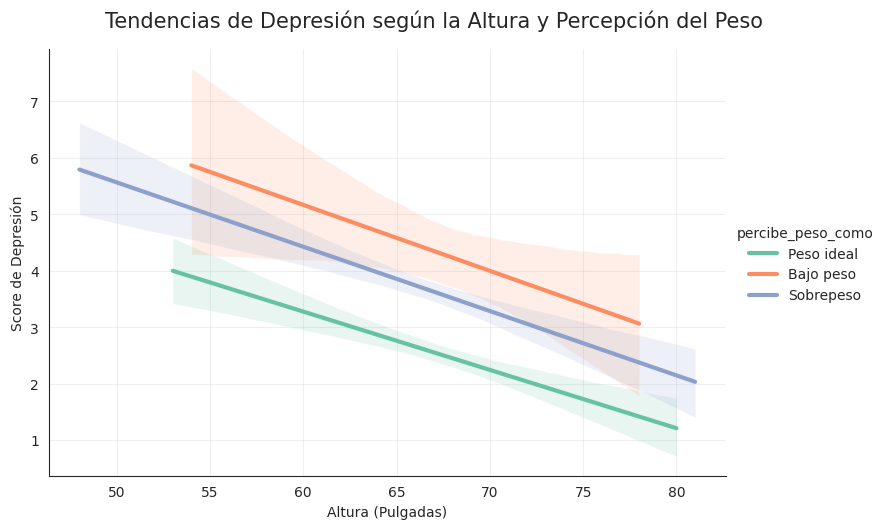

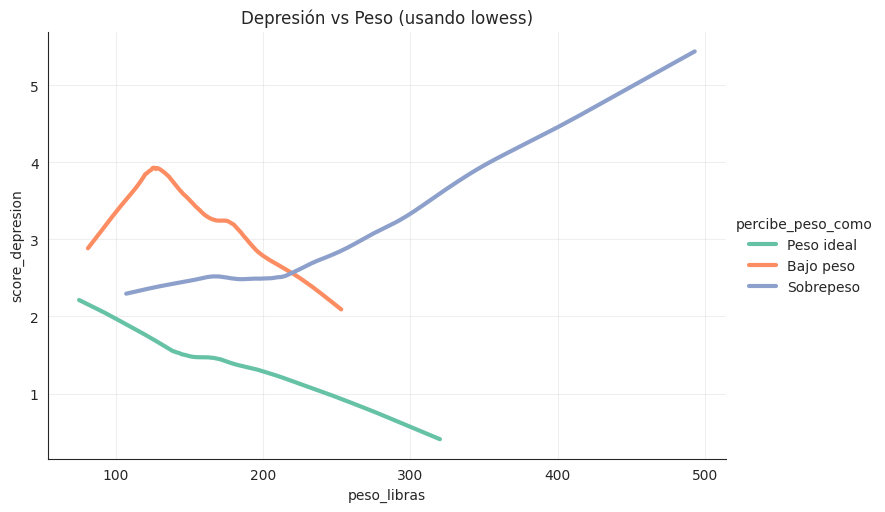

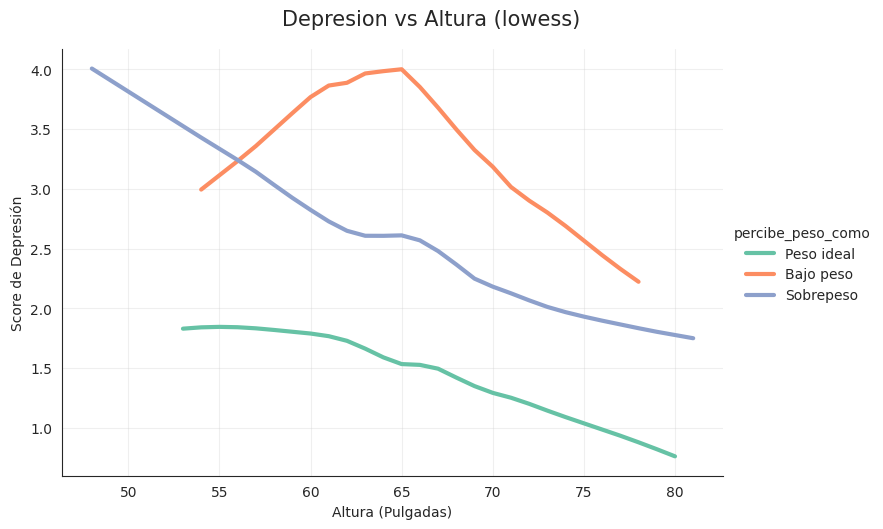

In [565]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------------
# Gráfico 1: SOLO TENDENCIA Peso vs Depresión
# -------------------------------------------------------------------------
g1 = sns.lmplot(
    data=df_merged,
    x="peso_libras",
    y="score_depresion",
    hue="percibe_peso_como",
    aspect=1.5,
    palette="Set2",
    scatter=False,  # <--- ESTO ELIMINA LOS PUNTOS
    line_kws={"linewidth": 3},
)

g1.fig.suptitle(
    "Tendencias de Depresión según el Peso y su Percepción", fontsize=15, y=1.05
)
g1.set_axis_labels("Peso (Libras)", "Score de Depresión")
plt.grid(alpha=0.3)
plt.show()

# -------------------------------------------------------------------------
# Gráfico 2: SOLO TENDENCIA Altura vs Depresión
# -------------------------------------------------------------------------
g2 = sns.lmplot(
    data=df_merged,
    x="altura_pulgadas",
    y="score_depresion",
    hue="percibe_peso_como",
    aspect=1.5,
    palette="Set2",
    scatter=False,  # <--- ESTO ELIMINA LOS PUNTOS
    line_kws={"linewidth": 3},
)

g2.fig.suptitle(
    "Tendencias de Depresión según la Altura y Percepción del Peso", fontsize=15, y=1.05
)
g2.set_axis_labels("Altura (Pulgadas)", "Score de Depresión")
plt.grid(alpha=0.3)
plt.show()
g1_lowess = sns.lmplot(
    data=df_merged,
    x="peso_libras",
    y="score_depresion",
    hue="percibe_peso_como",
    aspect=1.5,
    palette="Set2",
    scatter=False,
    lowess=True,  # <--- Agregas esto
    line_kws={"linewidth": 3},
)
plt.title("Depresión vs Peso (usando lowess)")
plt.grid(alpha=0.3)
plt.show()
g2 = sns.lmplot(
    data=df_merged,
    x="altura_pulgadas",
    y="score_depresion",
    hue="percibe_peso_como",
    lowess=True,  # <--- Agregas esto
    aspect=1.5,
    palette="Set2",
    scatter=False,  # <--- ESTO ELIMINA LOS PUNTOS
    line_kws={"linewidth": 3},
)

g2.fig.suptitle(
    "Depresion vs Altura (lowess)", fontsize=15, y=1.05
)
g2.set_axis_labels("Altura (Pulgadas)", "Score de Depresión")
plt.grid(alpha=0.3)
plt.show()

In [566]:
# Ejemplo para el pico naranja cerca de 120 lbs
print(df_merged[(df_merged['peso_libras'].between(110, 130)) & 
                (df_merged['percibe_peso_como'] == 'Bajo peso')].shape[0])

72


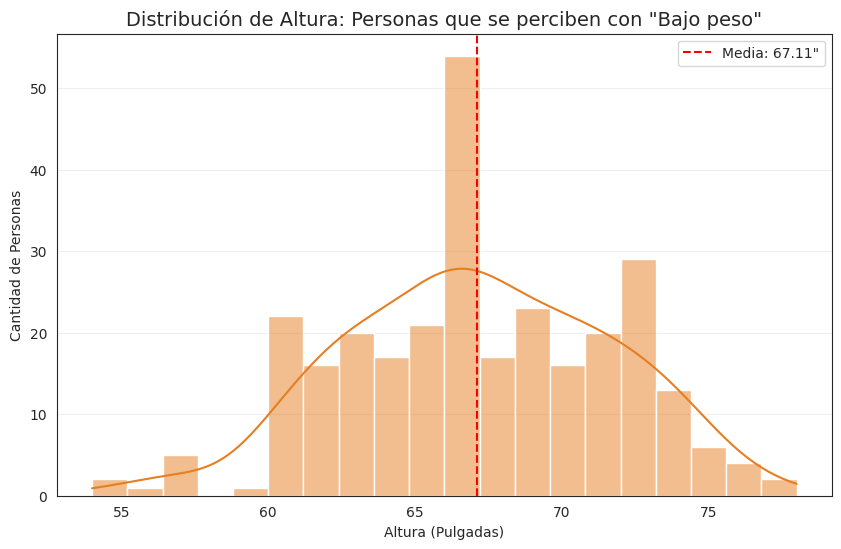

Estadísticas de Altura (Grupo Bajo Peso):
count    289.000000
mean      67.107266
std        4.537527
min       54.000000
25%       64.000000
50%       67.000000
75%       71.000000
max       78.000000
Name: altura_pulgadas, dtype: float64
altura_pulgadas
67.0    29
66.0    25
69.0    23
65.0    21
71.0    20
63.0    20
68.0    17
64.0    17
62.0    16
70.0    16
72.0    15
73.0    14
74.0    13
60.0    11
61.0    11
75.0     6
57.0     5
76.0     4
55.0     1
59.0     1
78.0     1
54.0     1
56.0     1
77.0     1
Name: count, dtype: int64


In [567]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos el grupo que se percibe como "Bajo peso"
df_bajo_peso = df_merged[df_merged['percibe_peso_como'] == 'Bajo peso']

# 2. Gráfico de Distribución (Histograma + Densidad)
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_bajo_peso, 
    x='altura_pulgadas', 
    kde=True, 
    color='#e67e22', # Naranja para mantener tu código de colores
    bins=20
)

# Añadimos la línea de la media para este grupo
media_h = df_bajo_peso['altura_pulgadas'].mean()
plt.axvline(media_h, color='red', linestyle='--', label=f'Media: {media_h:.2f}"')

plt.title('Distribución de Altura: Personas que se perciben con "Bajo peso"', fontsize=14)
plt.xlabel('Altura (Pulgadas)')
plt.ylabel('Cantidad de Personas')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()



# Estadísticos descriptivos para tu análisis
print("Estadísticas de Altura (Grupo Bajo Peso):")
print(df_bajo_peso['altura_pulgadas'].describe())
print(df_bajo_peso['altura_pulgadas'].value_counts())

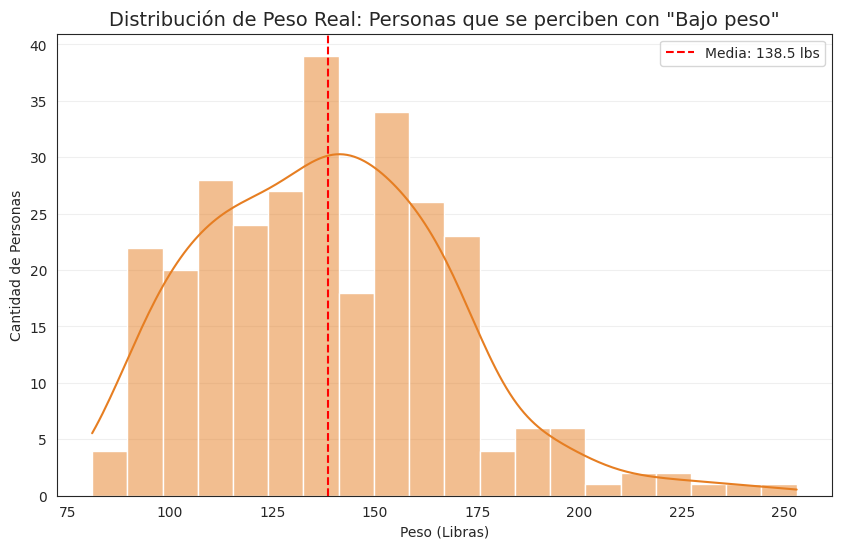

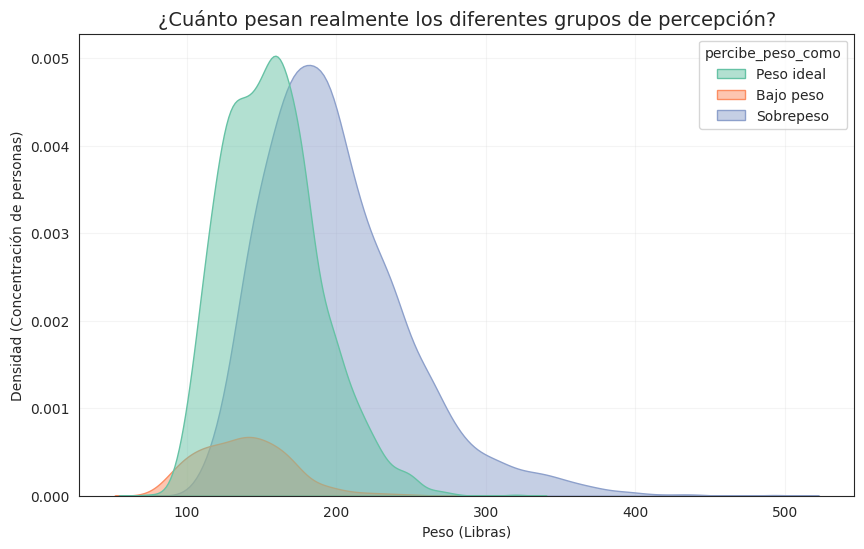

Estadísticas de Peso (Grupo Bajo Peso):
count    289.000000
mean     138.477509
std       30.332195
min       81.000000
25%      115.000000
50%      138.000000
75%      160.000000
max      253.000000
Name: peso_libras, dtype: float64


In [568]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos el grupo de interés
df_bajo_peso = df_merged[df_merged['percibe_peso_como'] == 'Bajo peso']

# 2. Gráfico de Distribución de Peso Real
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_bajo_peso, 
    x='peso_libras', 
    kde=True, 
    color='#e67e22', # Mantenemos el naranja para "Bajo peso"
    bins=20
)

# Añadimos la línea de la media de peso para este grupo
media_peso = df_bajo_peso['peso_libras'].mean()
plt.axvline(media_peso, color='red', linestyle='--', label=f'Media: {media_peso:.1f} lbs')

plt.title('Distribución de Peso Real: Personas que se perciben con "Bajo peso"', fontsize=14)
plt.xlabel('Peso (Libras)')
plt.ylabel('Cantidad de Personas')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Comparativa Multivariada: Pesos Reales vs Percepción
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_merged, 
    x='peso_libras', 
    hue='percibe_peso_como', 
    fill=True, 
    palette='Set2',
    alpha=0.5
)
plt.title('¿Cuánto pesan realmente los diferentes grupos de percepción?', fontsize=14)
plt.xlabel('Peso (Libras)')
plt.ylabel('Densidad (Concentración de personas)')
plt.grid(alpha=0.2)
plt.show()

# Estadísticos descriptivos de peso para este grupo
print("Estadísticas de Peso (Grupo Bajo Peso):")
print(df_bajo_peso['peso_libras'].describe())

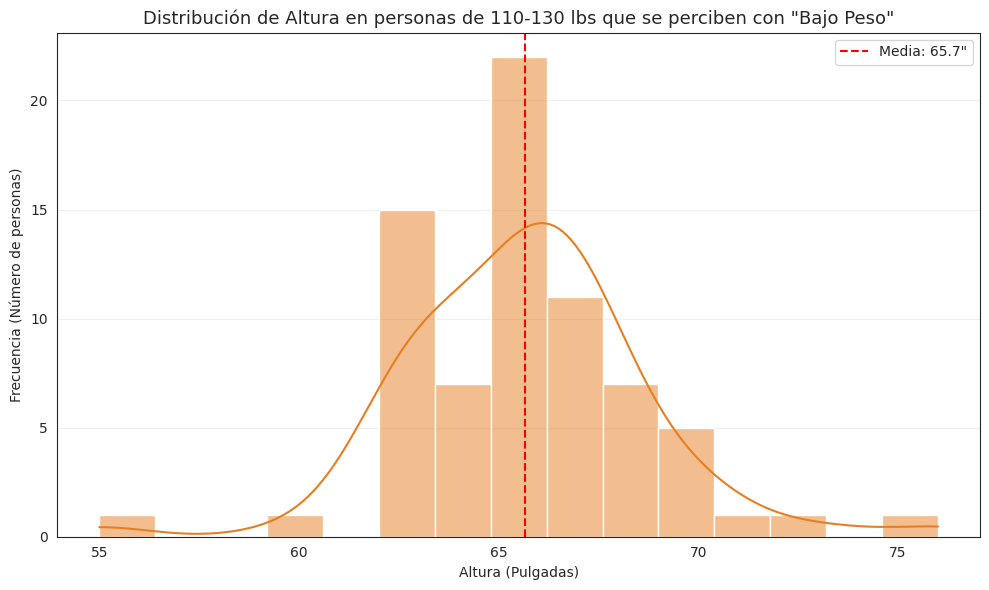

count    72.000000
mean     65.652778
std       3.003096
min      55.000000
25%      64.000000
50%      66.000000
75%      67.000000
max      76.000000
Name: altura_pulgadas, dtype: float64


In [569]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos el subgrupo de interés (las 72 personas)
df_subgrupo = df_merged[
    (df_merged['peso_libras'].between(110, 130)) & 
    (df_merged['percibe_peso_como'] == 'Bajo peso')
]

# 2. Creamos el gráfico de distribución de altura
plt.figure(figsize=(10, 6))

# Usamos un histograma con una línea de densidad (KDE)
sns.histplot(
    data=df_subgrupo, 
    x='altura_pulgadas', 
    kde=True, 
    color='#e67e22', # Color naranja para ser consistentes con tus gráficos anteriores
    bins=15
)

# Añadimos una línea para marcar la media de este grupo
plt.axvline(df_subgrupo['altura_pulgadas'].mean(), color='red', linestyle='--', label=f"Media: {df_subgrupo['altura_pulgadas'].mean():.1f}\"")

plt.title('Distribución de Altura en personas de 110-130 lbs que se perciben con "Bajo Peso"', fontsize=13)
plt.xlabel('Altura (Pulgadas)')
plt.ylabel('Frecuencia (Número de personas)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Opcional: Ver los estadísticos rápidos
print(df_subgrupo['altura_pulgadas'].describe())